In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

from ugdatalab.models.sdss import SDSSData
from ugdatalab.paths import CONTINUUM_PIXELS_PATH
from ugdatalab.spectra import (
    _get_spectra,
    APOGEE_PIXMASK,
    bitmask_summary,
    chip_wavelength_ranges,
)
from ugdatalab.lab2_plotting import (
    FIELD_DISPLAY,
    LABEL_NAMES,
    LABELS,
    plot_bitmask_spectrum,
    plot_combined_corner,
    plot_field_corners,
    plot_normalized_spectrum,
    plot_spectrum,
)


The archive is unstable and may perform below expectations. Please avoid launching intense Python query showers. Please contact the Gaia helpdesk in case of questions (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk). Workaround solutions for the issues following the recent infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive


In [2]:
query = """
SELECT s.*, a.*
FROM apogeeStar AS s
JOIN aspcapStar AS a ON s.apogee_id = a.apogee_id
WHERE s.field IN ('M15', 'N6791', 'K2_C4_168-21', '060+00')
"""

sdss = SDSSData(query)
data = sdss.data
print(f"Training set size: {len(data)} stars")
data[:3]


Training set size: 2335 stars


apstar_id,target_id,alt_id,file,apogee_id,telescope,location_id,field,ra,dec,glon,glat,apogee_target1,apogee_target2,apogee2_target1,apogee2_target2,apogee2_target3,apogee2_target4,min_h,max_h,min_jk,max_jk,survey,extratarg,nvisits,snr,starflag,andflag,vhelio_avg,vscatter,verr,rv_teff,rv_logg,rv_feh,rv_alpha,rv_carb,rv_ccfwhm,rv_autofwhm,rv_flag,n_components,gaiaedr3_source_id,gaiaedr3_parallax,gaiaedr3_parallax_error,gaiaedr3_pmra,gaiaedr3_pmra_error,gaiaedr3_pmdec,gaiaedr3_pmdec_error,gaiaedr3_phot_g_mean_mag,gaiaedr3_phot_bp_mean_mag,gaiaedr3_phot_rp_mean_mag,gaiaedr3_dr2_radial_velocity,gaiaedr3_dr2_radial_velocity_error,gaiaedr3_r_med_geo,gaiaedr3_r_lo_geo,gaiaedr3_r_hi_geo,gaiaedr3_r_med_photogeo,gaiaedr3_r_lo_photogeo,gaiaedr3_r_hi_photogeo,htmID,apogee_id1,target_id1,apstar_id1,aspcap_id,teff,teff_err,teff_flag,teff_spec,logg,logg_err,logg_flag,logg_spec,vmicro,vmacro,vsini,m_h,m_h_err,m_h_flag,alpha_m,alpha_m_err,alpha_m_flag,aspcap_chi2,aspcap_grid,aspcapflag,frac_badpix,frac_lowsnr,frac_sigsky,fparam_teff,fparam_logg,fparam_logvmicro,fparam_m_h,fparam_c_m,fparam_n_m,fparam_alpha_m,param_c_m,param_c_m_flag,param_n_m,param_n_m_flag,c_fe,c_fe_err,c_fe_flag,ci_fe,ci_fe_err,ci_fe_flag,n_fe,n_fe_err,n_fe_flag,o_fe,o_fe_err,o_fe_flag,na_fe,na_fe_err,na_fe_flag,mg_fe,mg_fe_err,mg_fe_flag,al_fe,al_fe_err,al_fe_flag,si_fe,si_fe_err,si_fe_flag,p_fe,p_fe_err,p_fe_flag,s_fe,s_fe_err,s_fe_flag,k_fe,k_fe_err,k_fe_flag,ca_fe,ca_fe_err,ca_fe_flag,ti_fe,ti_fe_err,ti_fe_flag,tiii_fe,tiii_fe_err,tiii_fe_flag,v_fe,v_fe_err,v_fe_flag,cr_fe,cr_fe_err,cr_fe_flag,mn_fe,mn_fe_err,mn_fe_flag,fe_h,fe_h_err,fe_h_flag,co_fe,co_fe_err,co_fe_flag,ni_fe,ni_fe_err,ni_fe_flag,cu_fe,cu_fe_err,cu_fe_flag,ce_fe,ce_fe_err,ce_fe_flag,felem_c_m,felem_c_m_err,felem_ci_m,felem_ci_m_err,felem_n_m,felem_n_m_err,felem_o_m,felem_o_m_err,felem_na_h,felem_na_h_err,felem_mg_m,felem_mg_m_err,felem_al_h,felem_al_h_err,felem_si_m,felem_si_m_err,felem_p_m,felem_p_m_err,felem_s_m,felem_s_m_err,felem_k_h,felem_k_h_err,felem_ca_m,felem_ca_m_err,felem_ti_m,felem_ti_m_err,felem_tiii_m,felem_tiii_m_err,felem_v_h,felem_v_h_err,felem_cr_h,felem_cr_h_err,felem_mn_h,felem_mn_h_err,felem_fe_h,felem_fe_h_err,felem_co_h,felem_co_h_err,felem_ni_h,felem_ni_h_err,felem_cu_h,felem_cu_h_err,felem_ge_h,felem_ge_h_err,felem_rb_h,felem_rb_h_err,felem_ce_h,felem_ce_h_err,felem_nd_h,felem_nd_h_err,felem_yb_h,felem_yb_h_err
str51,str38,str4,str35,str18,str6,int64,str12,float64,float64,float64,float64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,str36,int64,int64,float64,int64,int64,float64,float64,float64,float64,float64,float64,int64,int64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,str18,str42,str55,str57,float64,float64,int64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,int64,float64,float64,int64,float64,str5,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,int64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,float64,float64,int64,int64,float64,int64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,float64,float64,float64,float64,int64,int64,float64,float64
apogee.apo25

In [3]:
# Constants (cgs)
G     = 6.674e-8   # cm^3 g^-1 s^-2
M_sun = 1.989e33   # g
R_sun = 6.957e10   # cm

M = M_sun  # solar-mass star

stages = {
    "Main sequence        (R = 1   R_sun)": 1,
    "Pre-helium flash     (R = 100 R_sun)": 100,
    "Core He burning      (R = 15  R_sun)": 15,
}

rows = []
for label, r_over_rsun in stages.items():
    R    = r_over_rsun * R_sun
    g    = G * M / R**2
    rows.append({"Stage": label, "g (cm/s²)": g, "log g": np.log10(g)})

df = pd.DataFrame(rows).set_index("Stage")
df


,g (cm/s²),log g
Stage,,
Main sequence (R = 1 R_sun),27426.916146,4.438177
Pre-helium flash (R = 100 R_sun),2.742692,0.438177
Core He burning (R = 15 R_sun),121.897405,2.085994


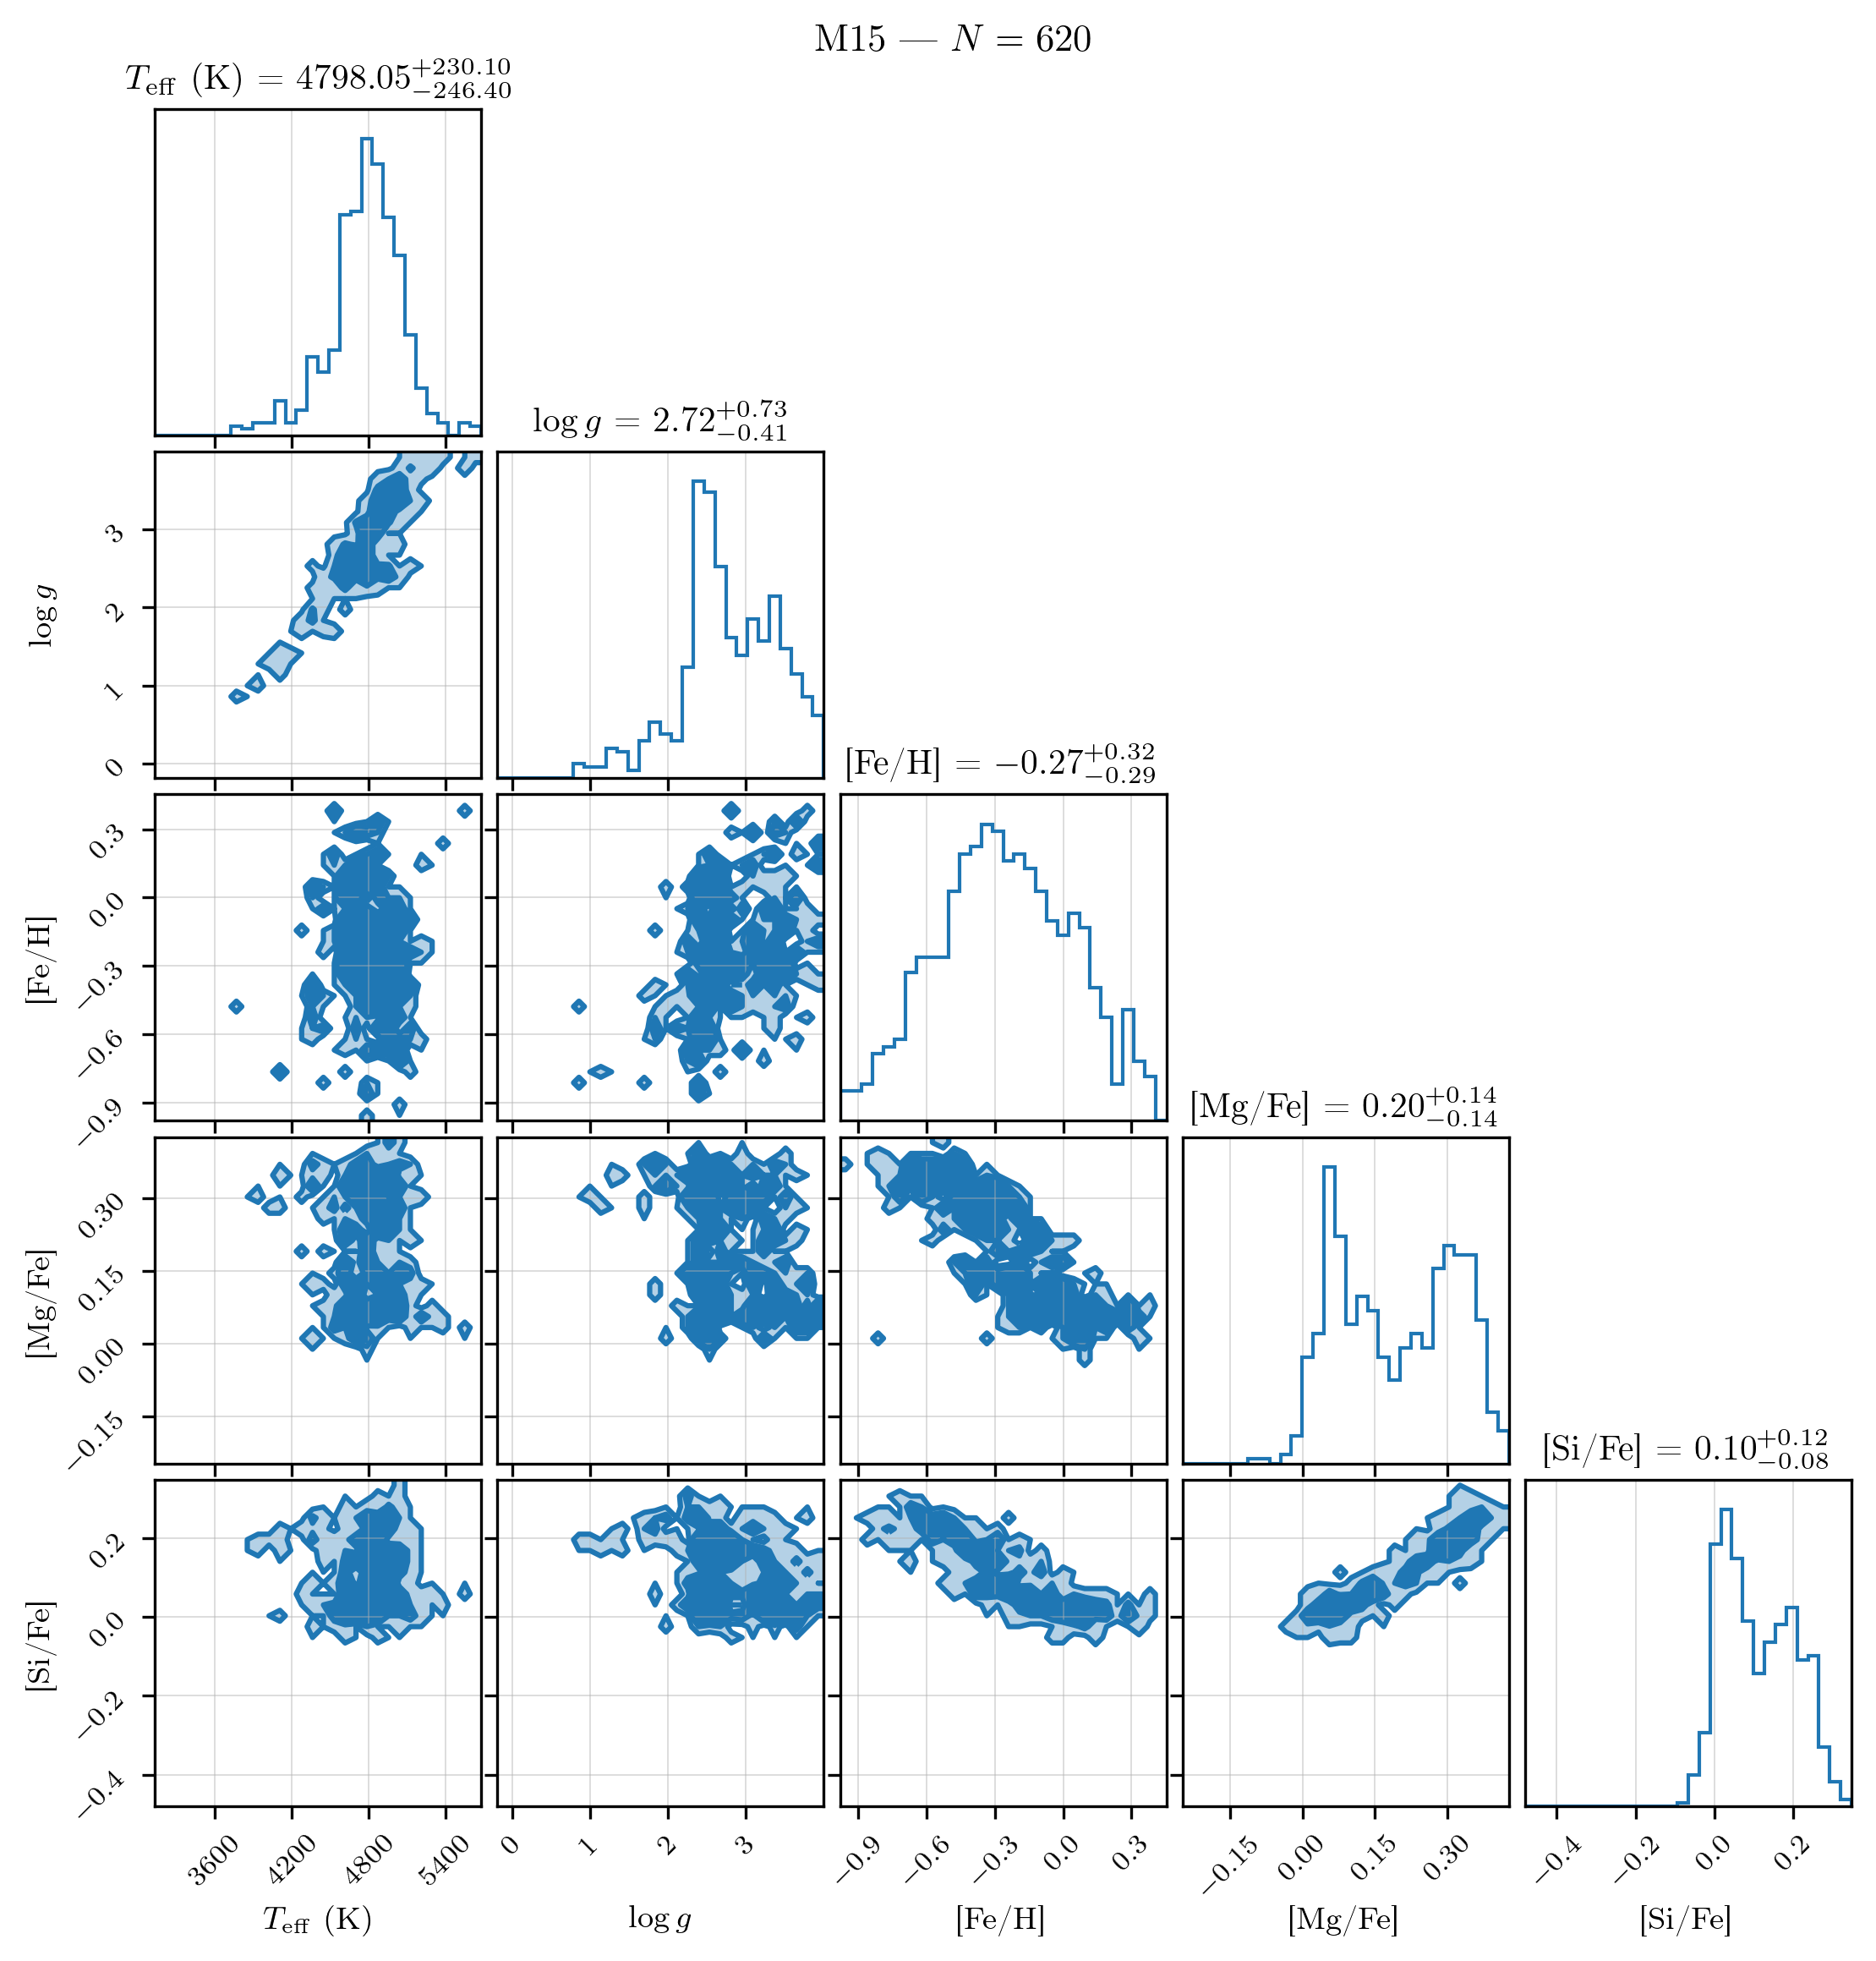

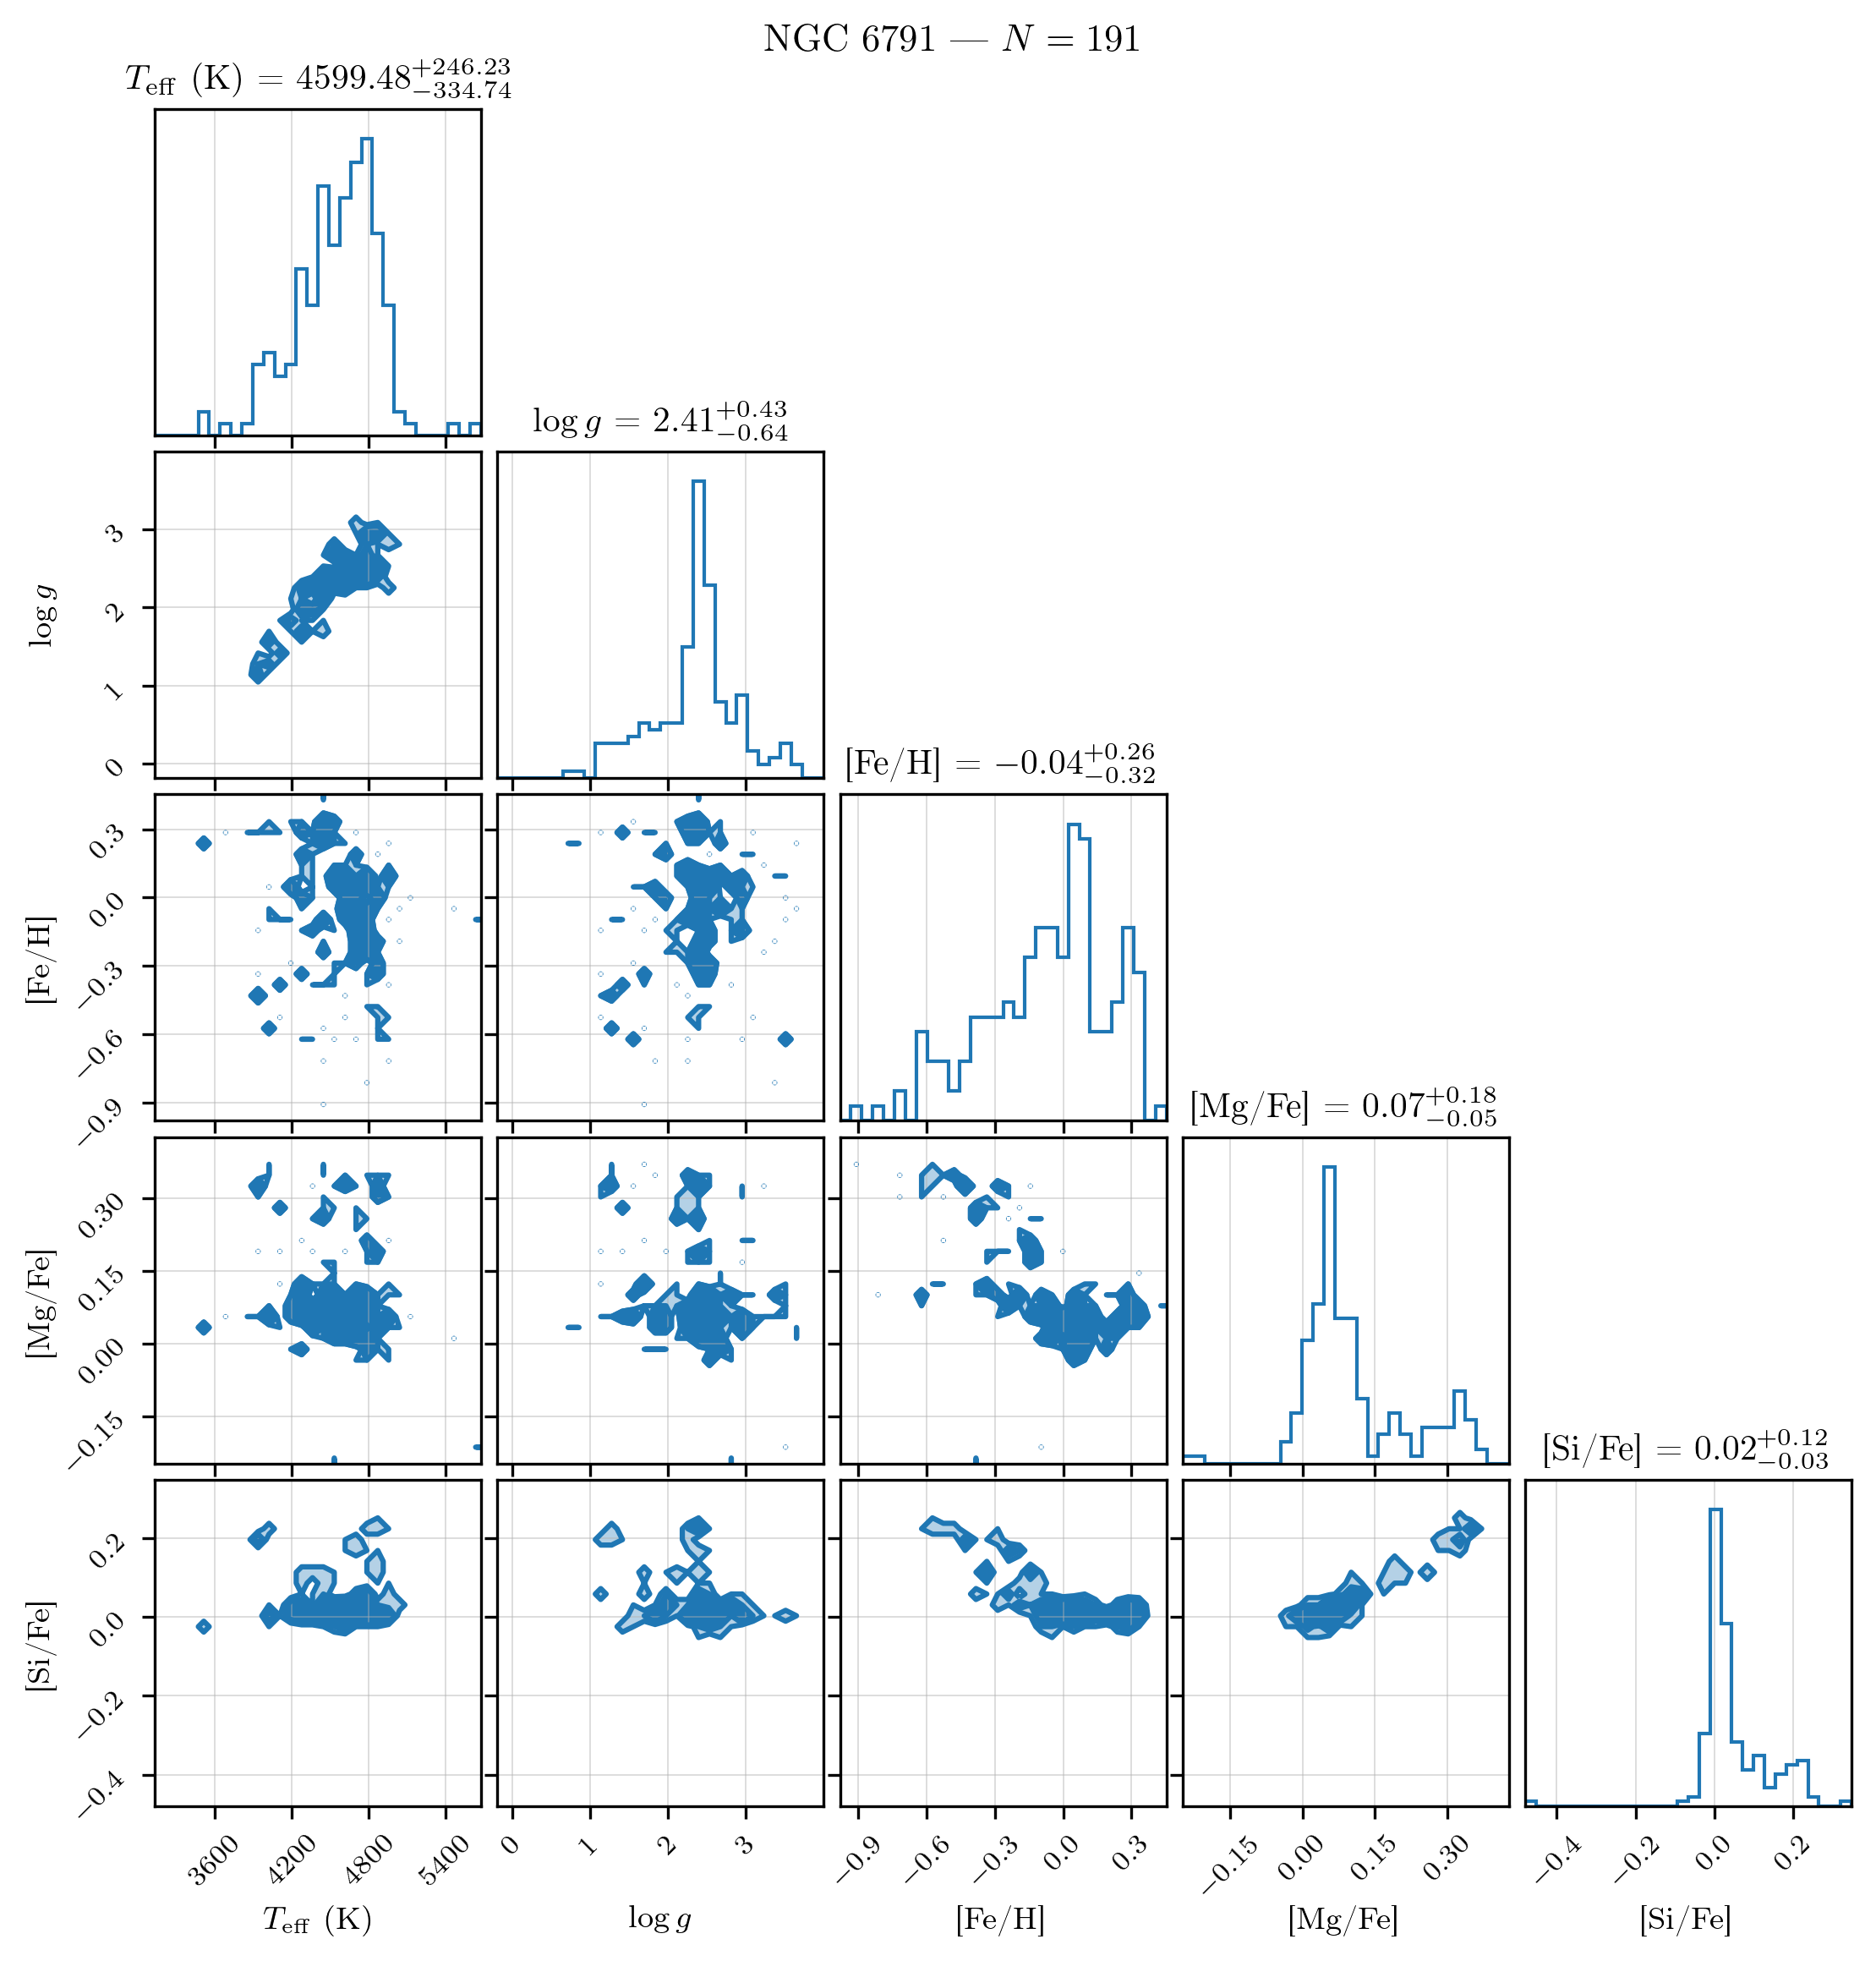

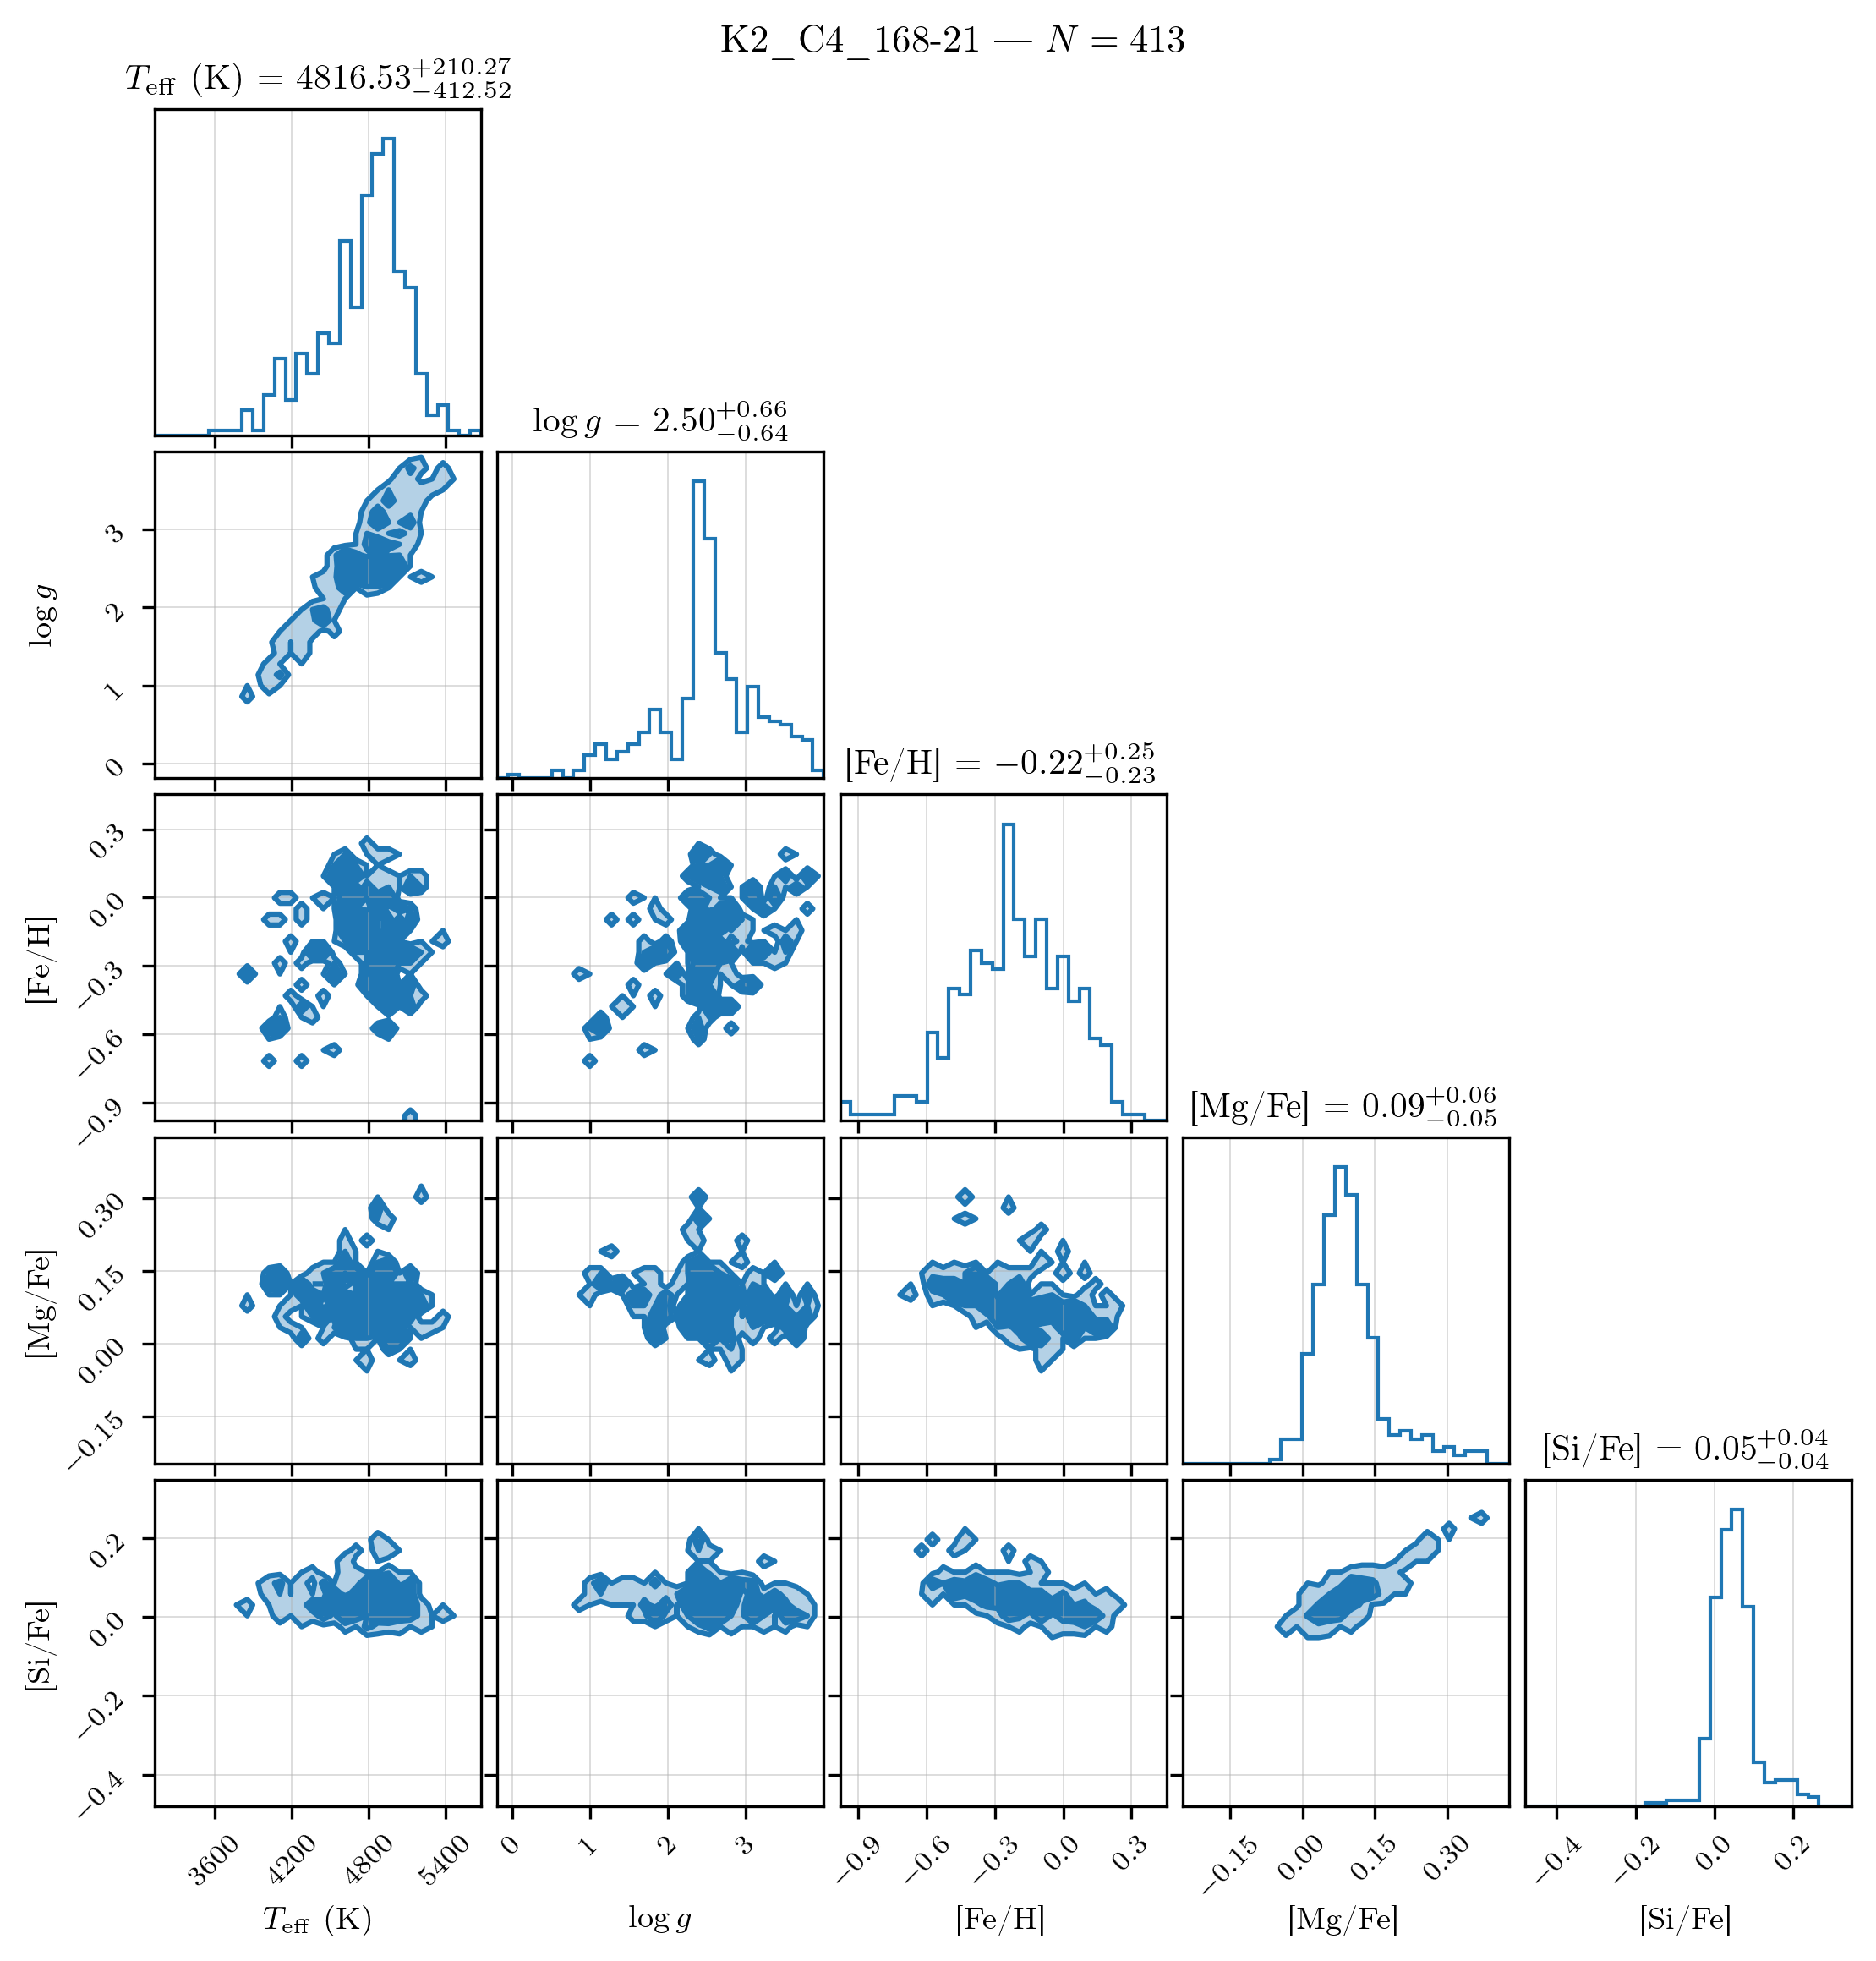

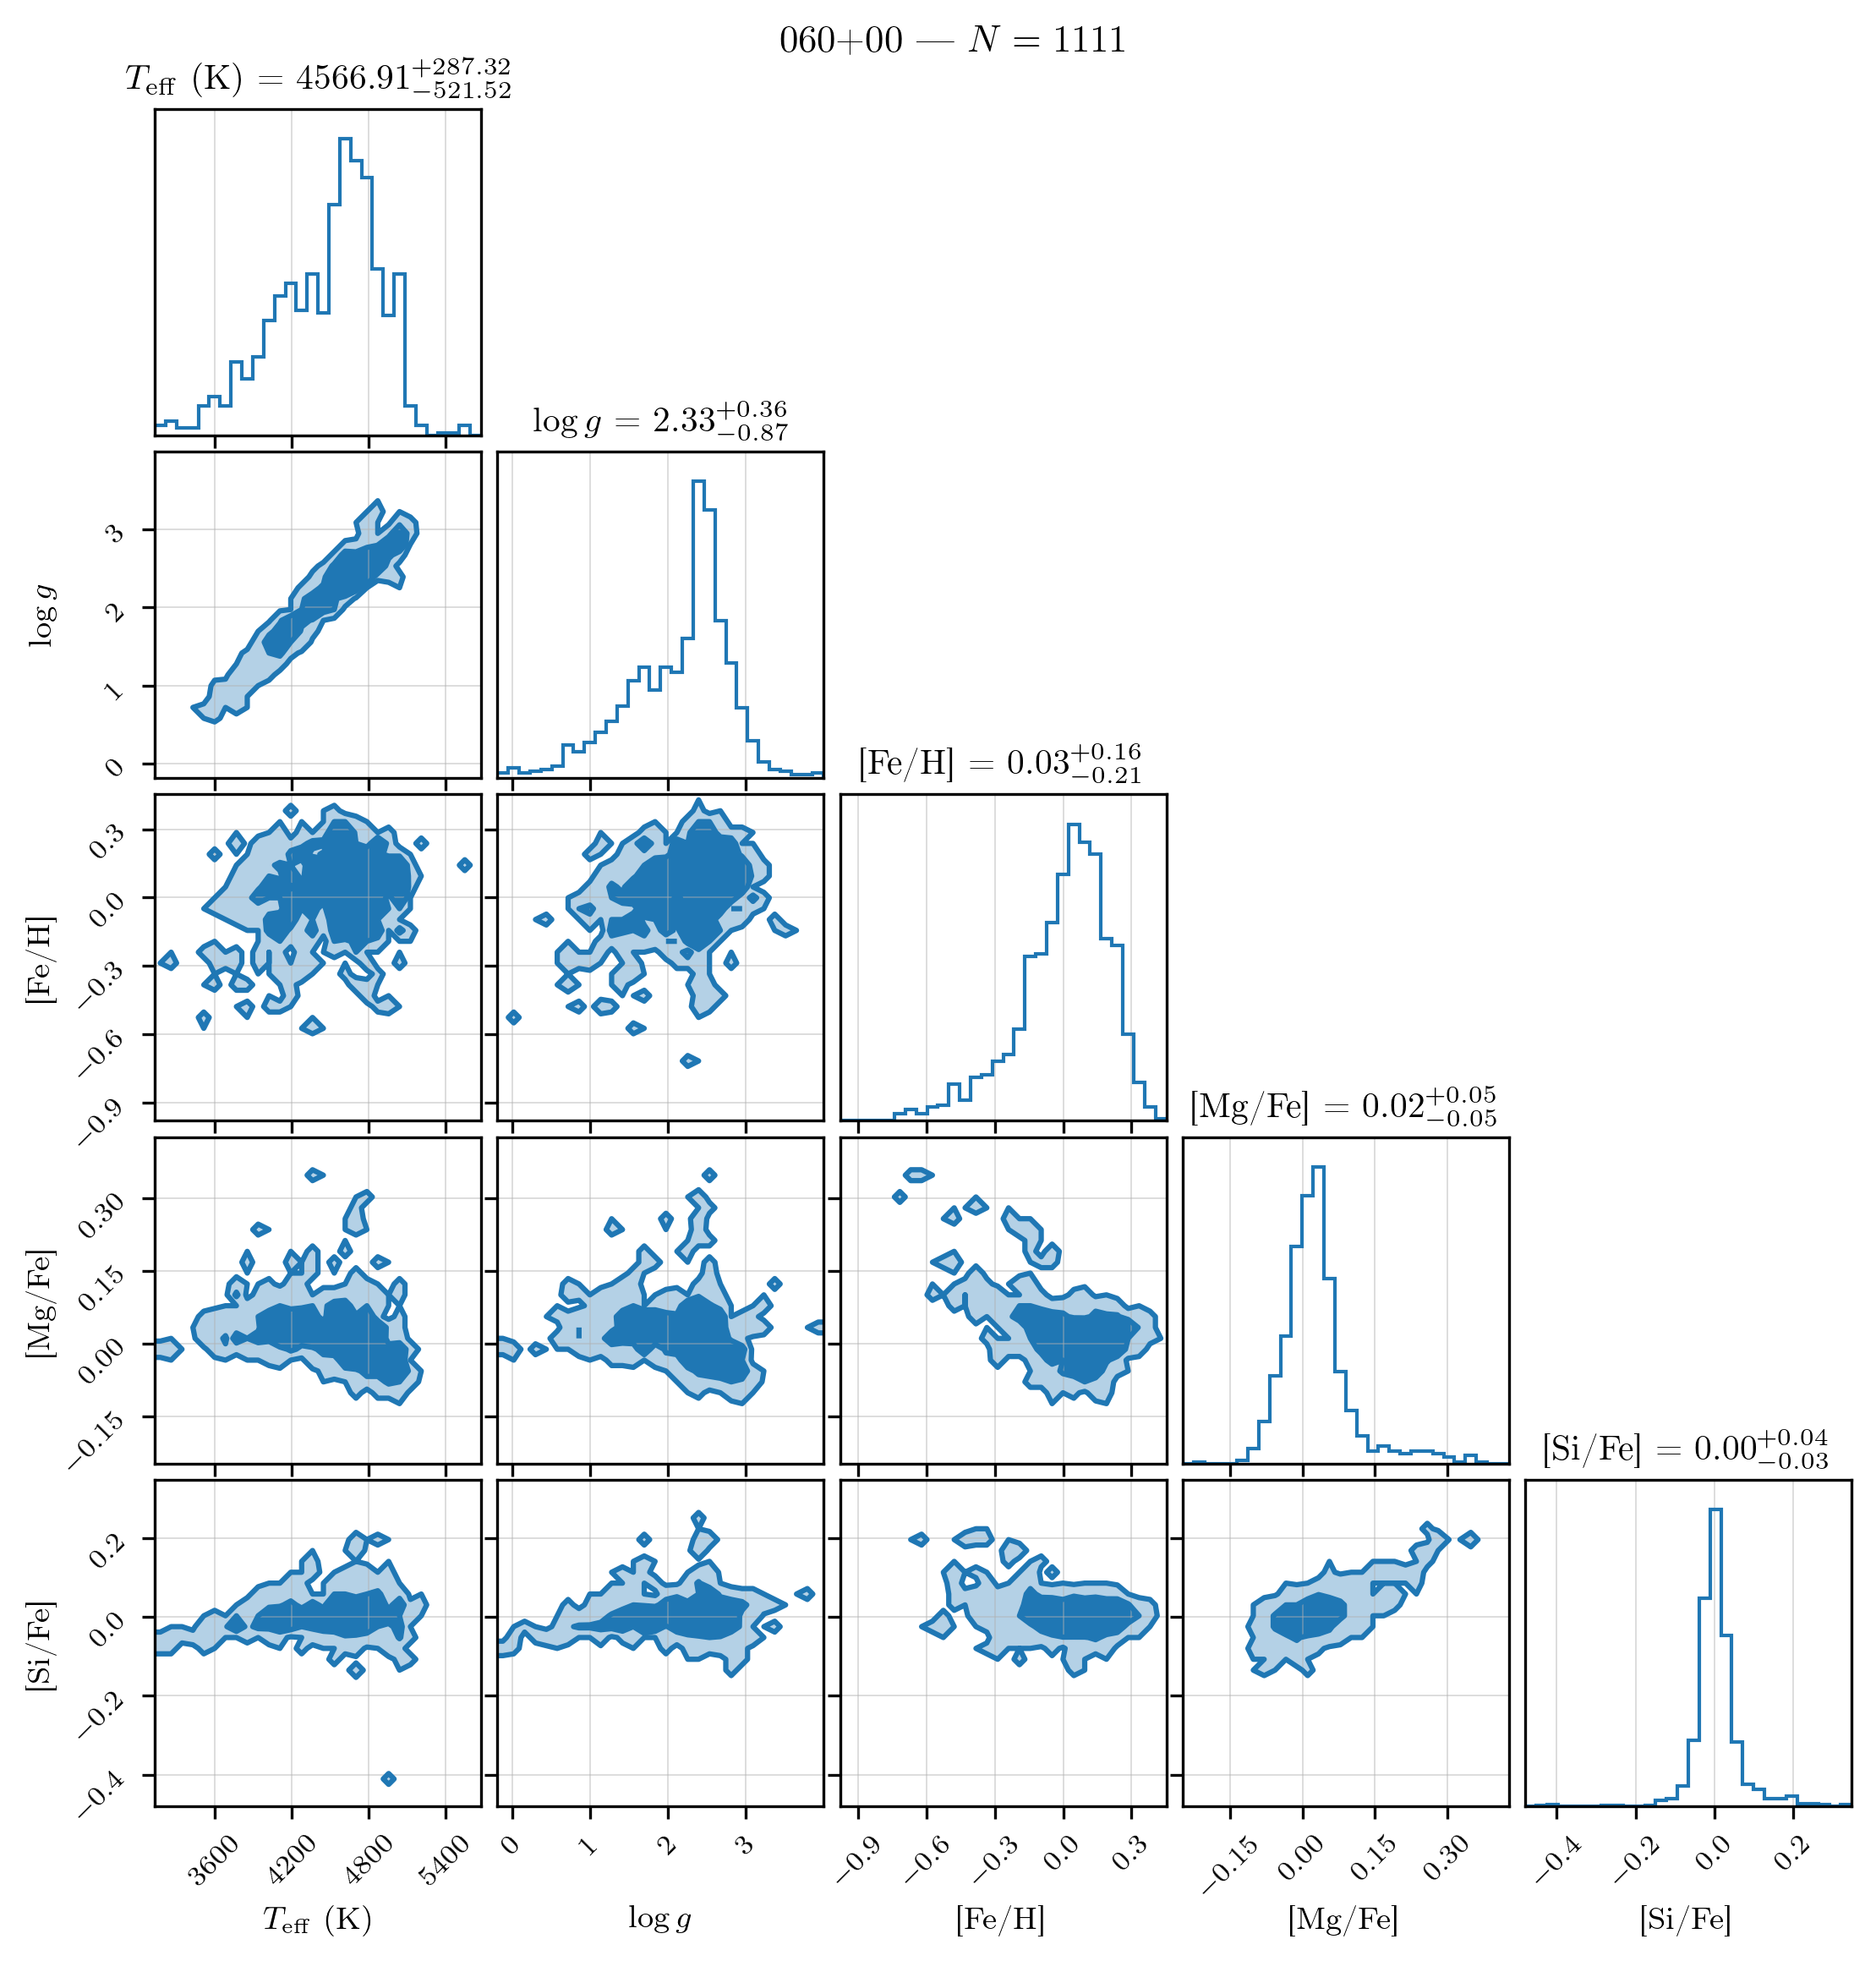

In [4]:
figs = plot_field_corners(data, LABELS, LABEL_NAMES, FIELD_DISPLAY, True)
for fig, (field, (display_name, _)) in zip(figs, FIELD_DISPLAY.items()):
    n = int((np.asarray(data["field"], dtype=str) == field).sum())
    fig.suptitle(rf"{display_name} — $N={n}$", y=1.01)
plt.show()


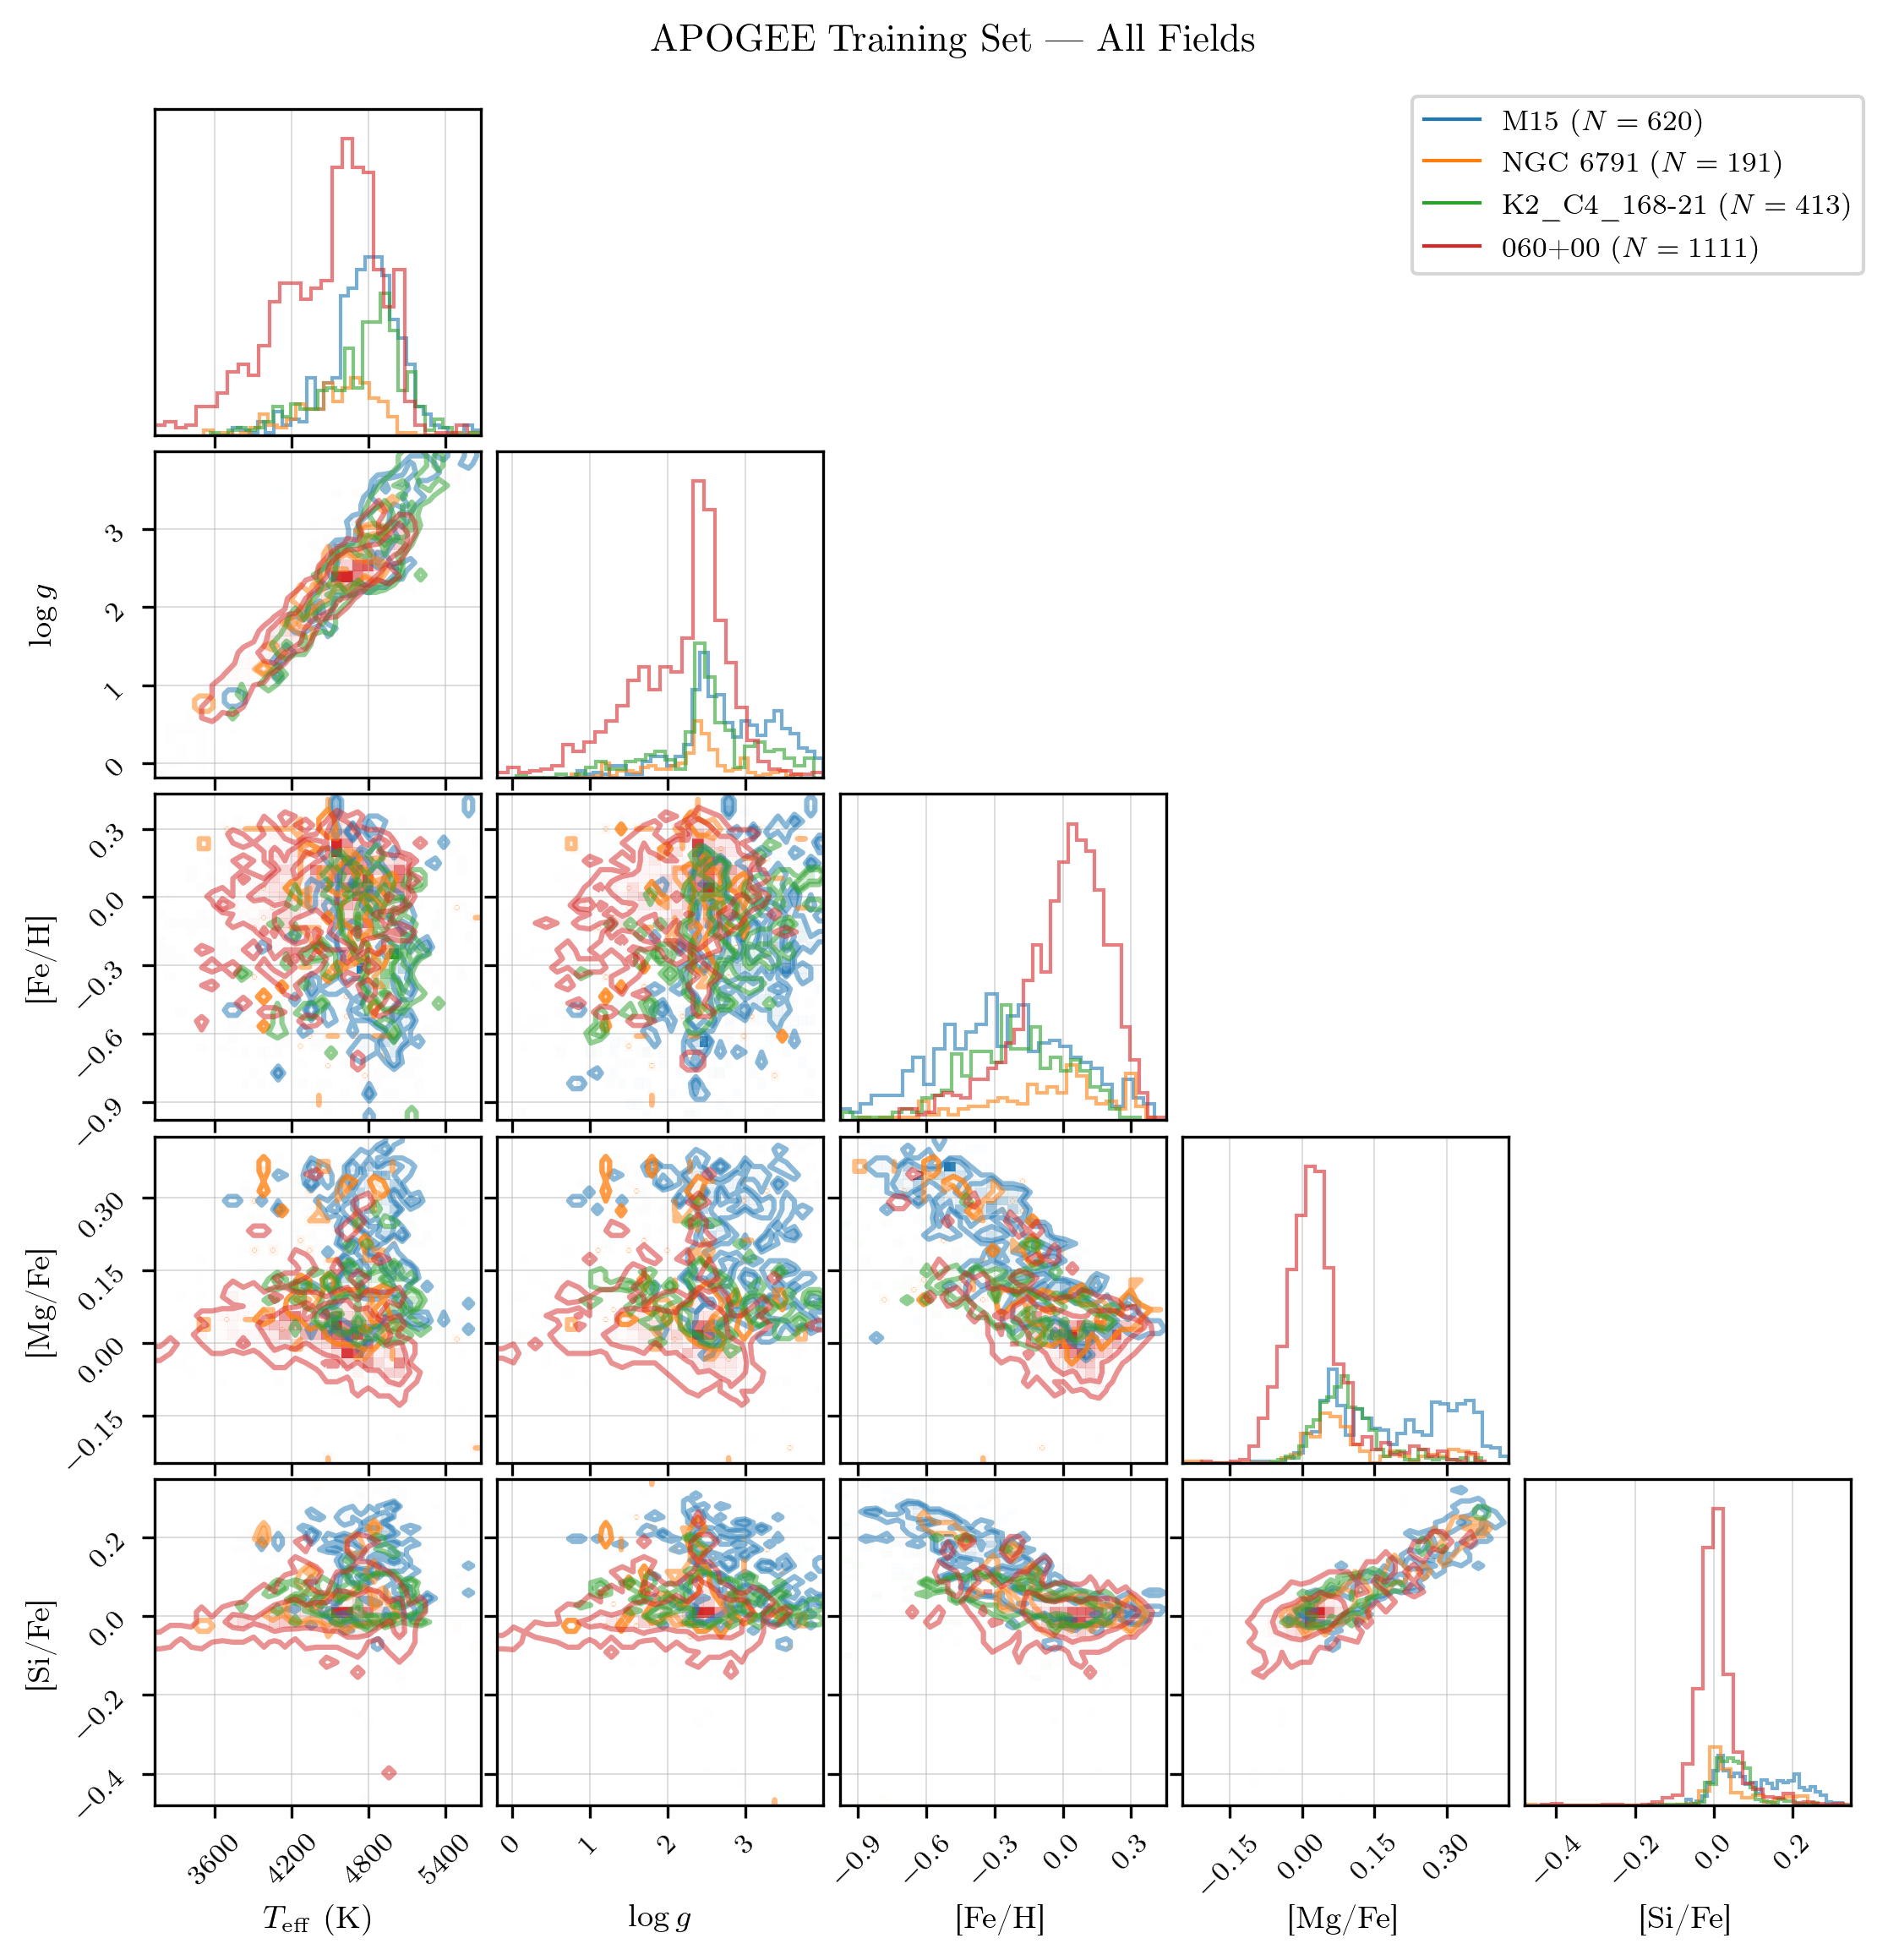

In [5]:
fig = plot_combined_corner(data, LABELS, LABEL_NAMES, FIELD_DISPLAY)
fig.suptitle("APOGEE Training Set — All Fields", y=1.01)
plt.show()


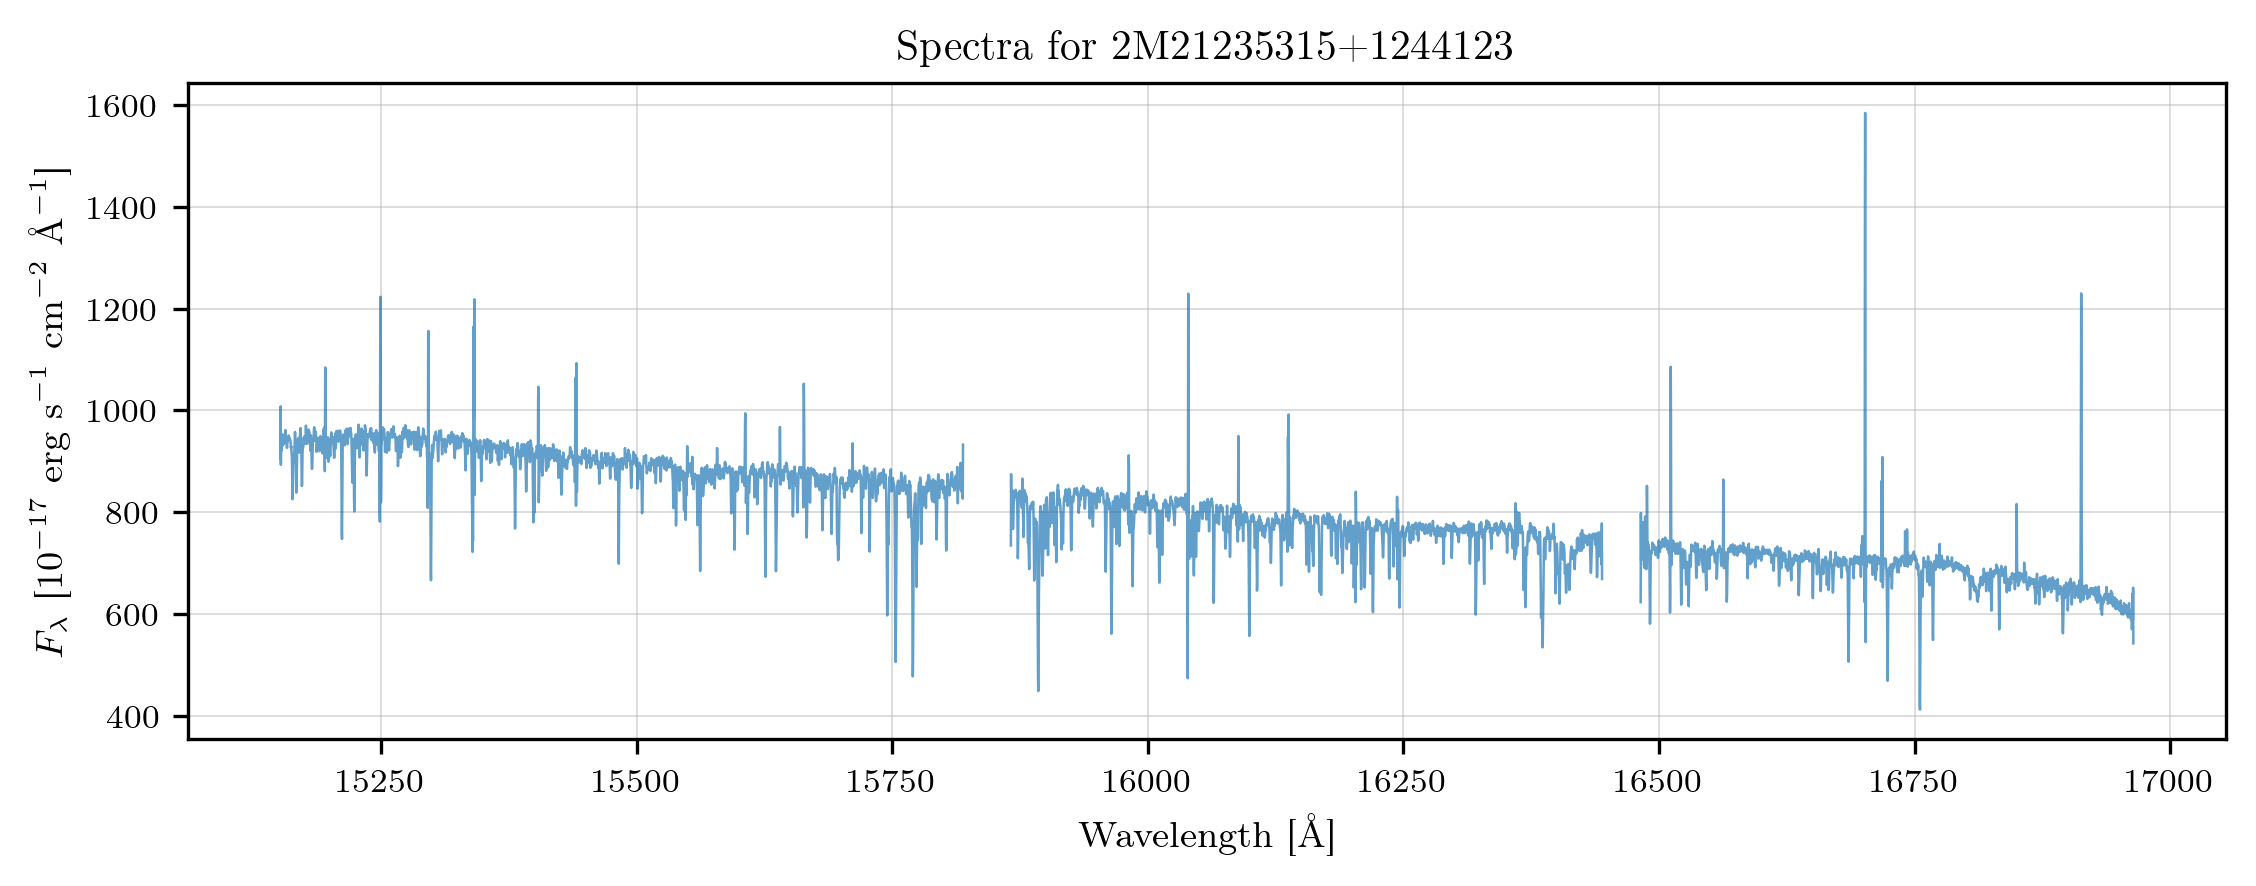

In [6]:
EXAMPLE_ID  = "2M21235315+1244123"
EXAMPLE_TEL = "apo25m"
EXAMPLE_FLD = "M15"

ids = np.asarray(data["apogee_id"], dtype=str)
row = data[int(np.where(ids == EXAMPLE_ID)[0][0])]

spec       = _get_spectra(EXAMPLE_ID, EXAMPLE_TEL, EXAMPLE_FLD)
wavelength = np.asarray(spec["wavelength"][0], dtype=float)
flux       = np.asarray(spec["flux"][0],       dtype=float)

ax = plot_spectrum(wavelength, flux)
ax.set_title(f"Spectra for {EXAMPLE_ID}")
plt.show()


In [7]:
df_pixmask = pd.DataFrame(
    [{"Name": name, "Description": desc} for name, desc in APOGEE_PIXMASK.values()],
    index=pd.Index(APOGEE_PIXMASK.keys(), name="Bit"),
)
df_pixmask


,Name,Description
Bit,,
0,BADPIX,Pixel flagged as bad in the bad-pixel mask
1,CRPIX,Cosmic-ray pixel
2,SATPIX,Saturated pixel
3,UNFIXABLE,Pixel could not be corrected by fixing bad col...
4,BADDARK,Dark current correction unreliable
5,BADFLAT,Flat-field correction unreliable
6,BADERR,Formal uncertainty is bad / negative
7,NOSKY,Sky-subtraction pixel unavailable
12,SIG_SKYLINE,Significant sky-line residual (>3σ)


Total pixels : 8575
Bad pixels   : 264 (3.1%)


,Name,Description,Flagged [pixels],Fraction [%]
Bit,,,,
0,BADPIX,Pixel flagged as bad in the bad-pixel mask,125,1.46
1,CRPIX,Cosmic-ray pixel,0,0.00
2,SATPIX,Saturated pixel,0,0.00
3,UNFIXABLE,Pixel could not be corrected by fixing bad col...,0,0.00
4,BADDARK,Dark current correction unreliable,71,0.83
5,BADFLAT,Flat-field correction unreliable,89,1.04
6,BADERR,Formal uncertainty is bad / negative,0,0.00
7,NOSKY,Sky-subtraction pixel unavailable,38,0.44
12,SIG_SKYLINE,Significant sky-line residual (>3σ),145,1.69


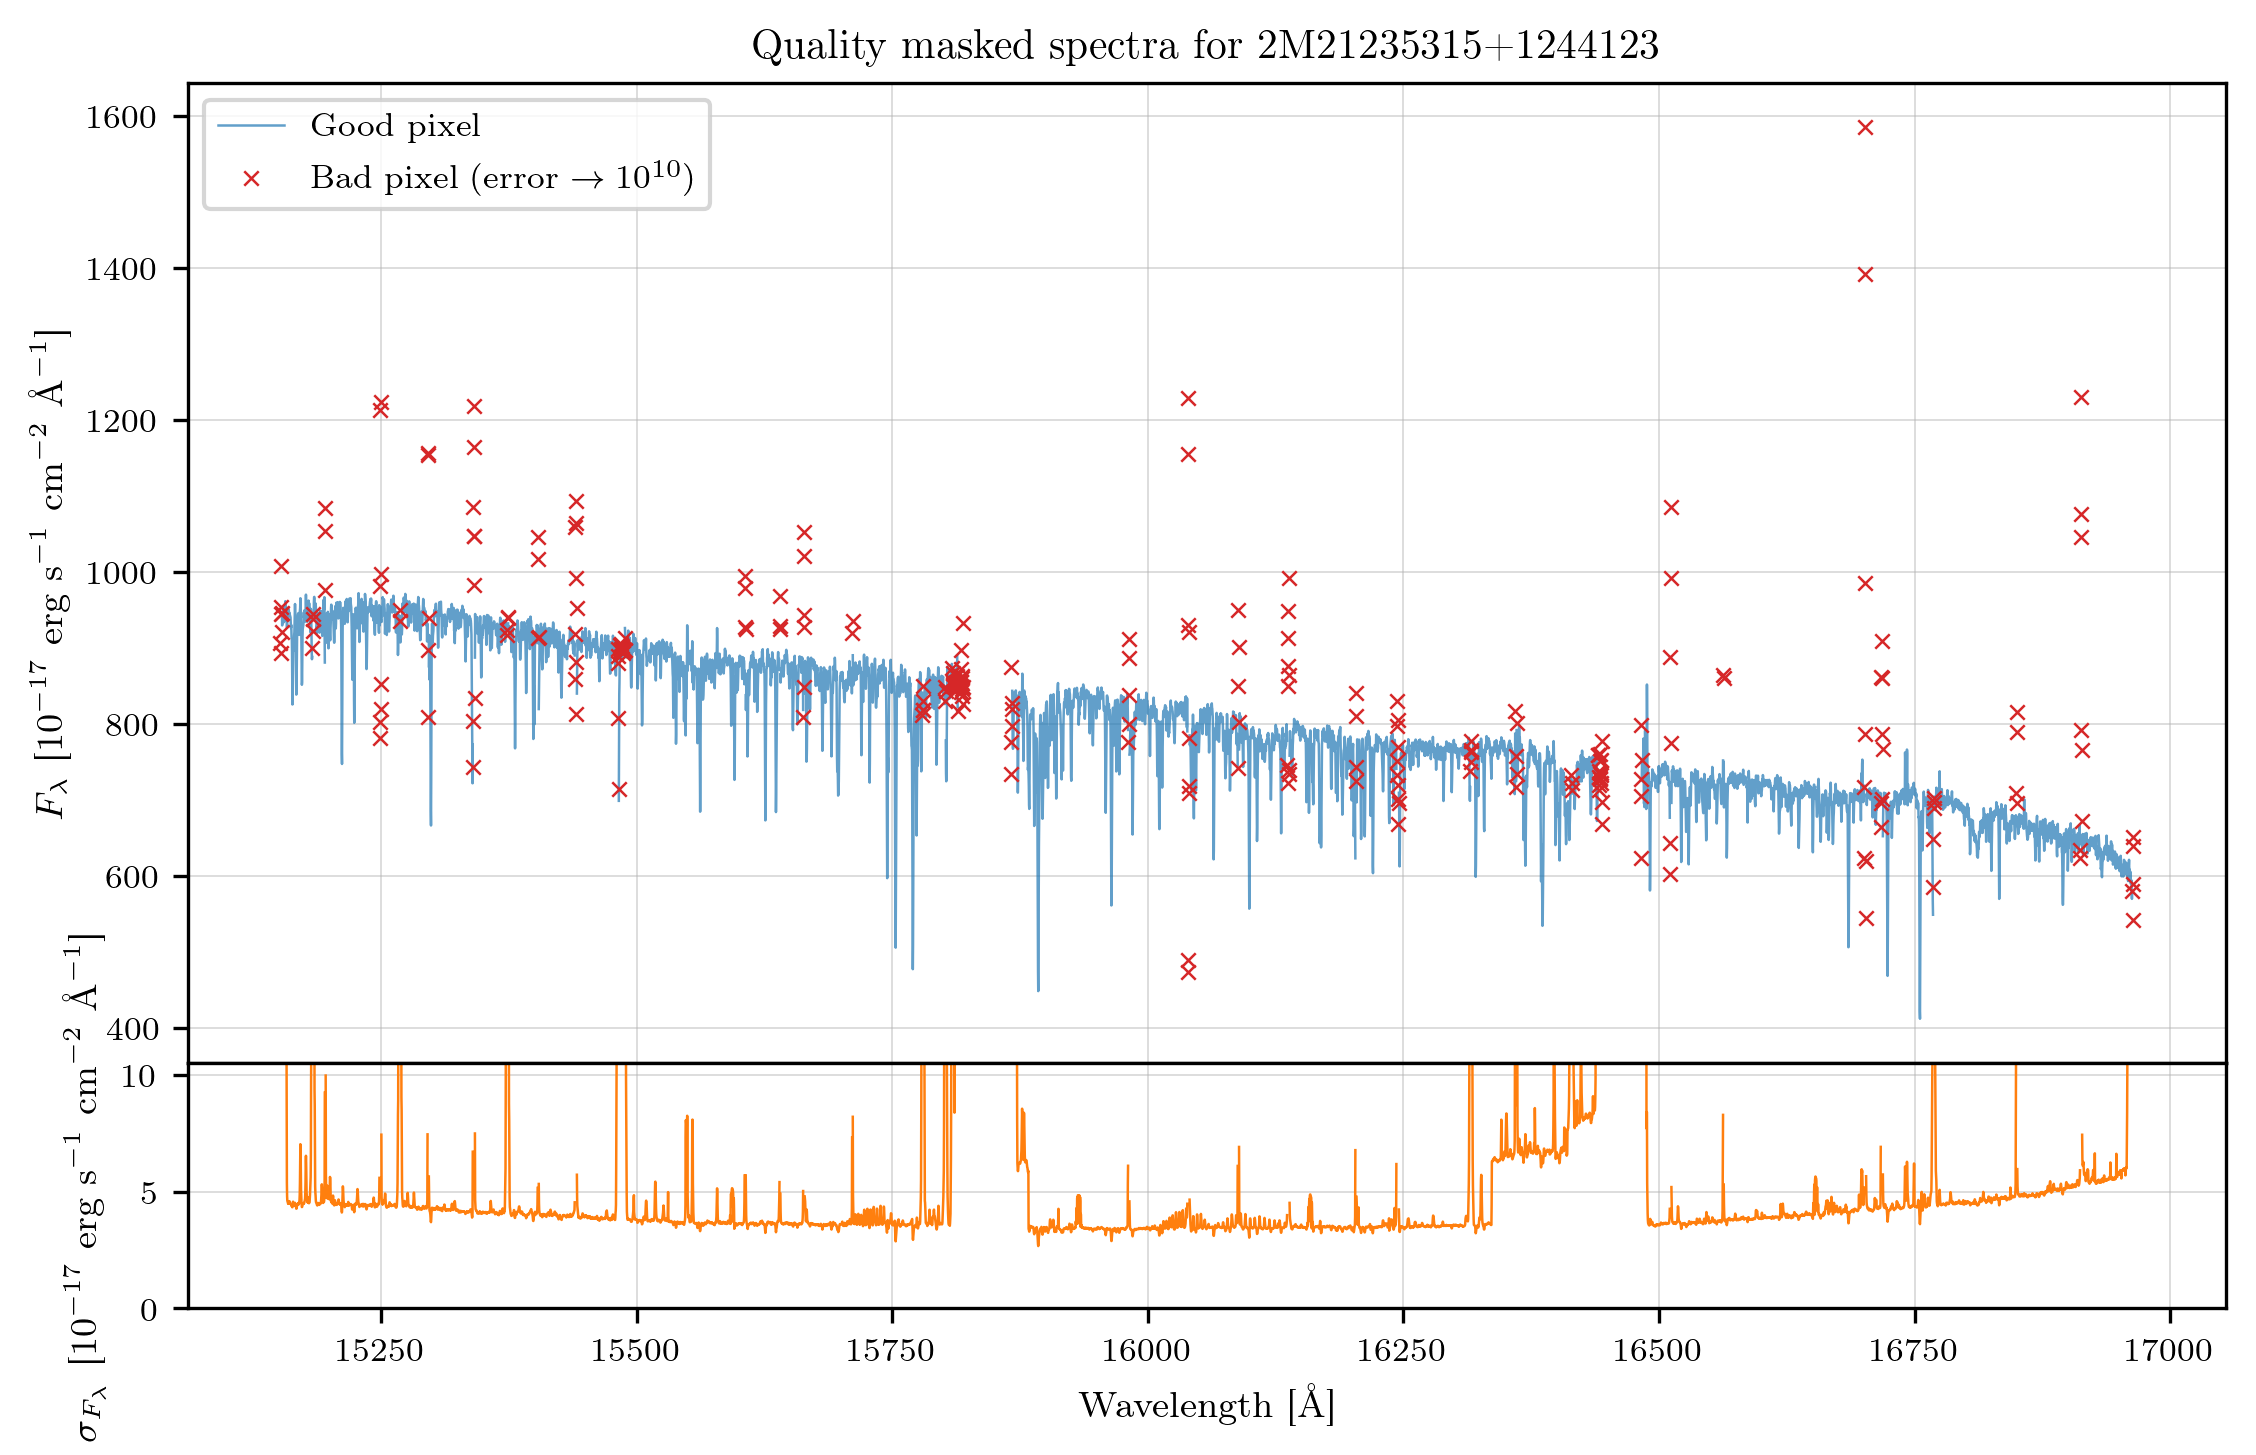

In [8]:
bad, flux_err, mask_rows = bitmask_summary(EXAMPLE_ID, EXAMPLE_TEL, EXAMPLE_FLD)

print(f"Total pixels : {len(bad)}")
print(f"Bad pixels   : {bad.sum()} ({100 * bad.mean():.1f}%)")

df_mask = pd.DataFrame(mask_rows).set_index("Bit")
display(df_mask)

ax_flux, ax_err = plot_bitmask_spectrum(EXAMPLE_ID, EXAMPLE_TEL, EXAMPLE_FLD)
ax_flux.set_title(f"Quality masked spectra for {EXAMPLE_ID}")
plt.show()


In [9]:
_cont     = np.load(CONTINUUM_PIXELS_PATH)
CONT_MASK = np.asarray(_cont["continuum"], dtype=bool)
print(f"Continuum pixels: {CONT_MASK.sum()} / {len(CONT_MASK)} "
      f"({100 * CONT_MASK.mean():.1f} %)")

chips_pixels = [tuple(r) for r in np.asarray(spec["chips_pixels"][0])]
CHIPS = chip_wavelength_ranges(wavelength, chips_pixels)
print(f"\nChip boundaries ({len(CHIPS)} chips):")
for i, (lo, hi) in enumerate(CHIPS):
    print(f"  Chip {i+1}: {lo:.1f} – {hi:.1f} Å")


Continuum pixels: 529 / 8575 (6.2 %)

Chip boundaries (3 chips):
  Chip 1: 15151.6 – 15819.2 Å
  Chip 2: 15866.0 – 16444.2 Å
  Chip 3: 16482.0 – 16963.9 Å


When fitting a polynomial to the continuum anchor pixels, since we want the simplest model that still explains the data well rather than a complex model that can potentially overfit, we consider

$$
\mathrm{AIC} = \chi^2 + 2k
\qquad
\mathrm{BIC} = \chi^2 + k\ln n
$$

where $\chi^2 = \sum_i \bigl((f_i - \hat{f}_i)/\sigma_i\bigr)^2$ is the fit residual, $k$ is the number of free parameters (degree $+$ 1, summed over all chips), and $n$ is the total number of anchor pixels used in the fit.


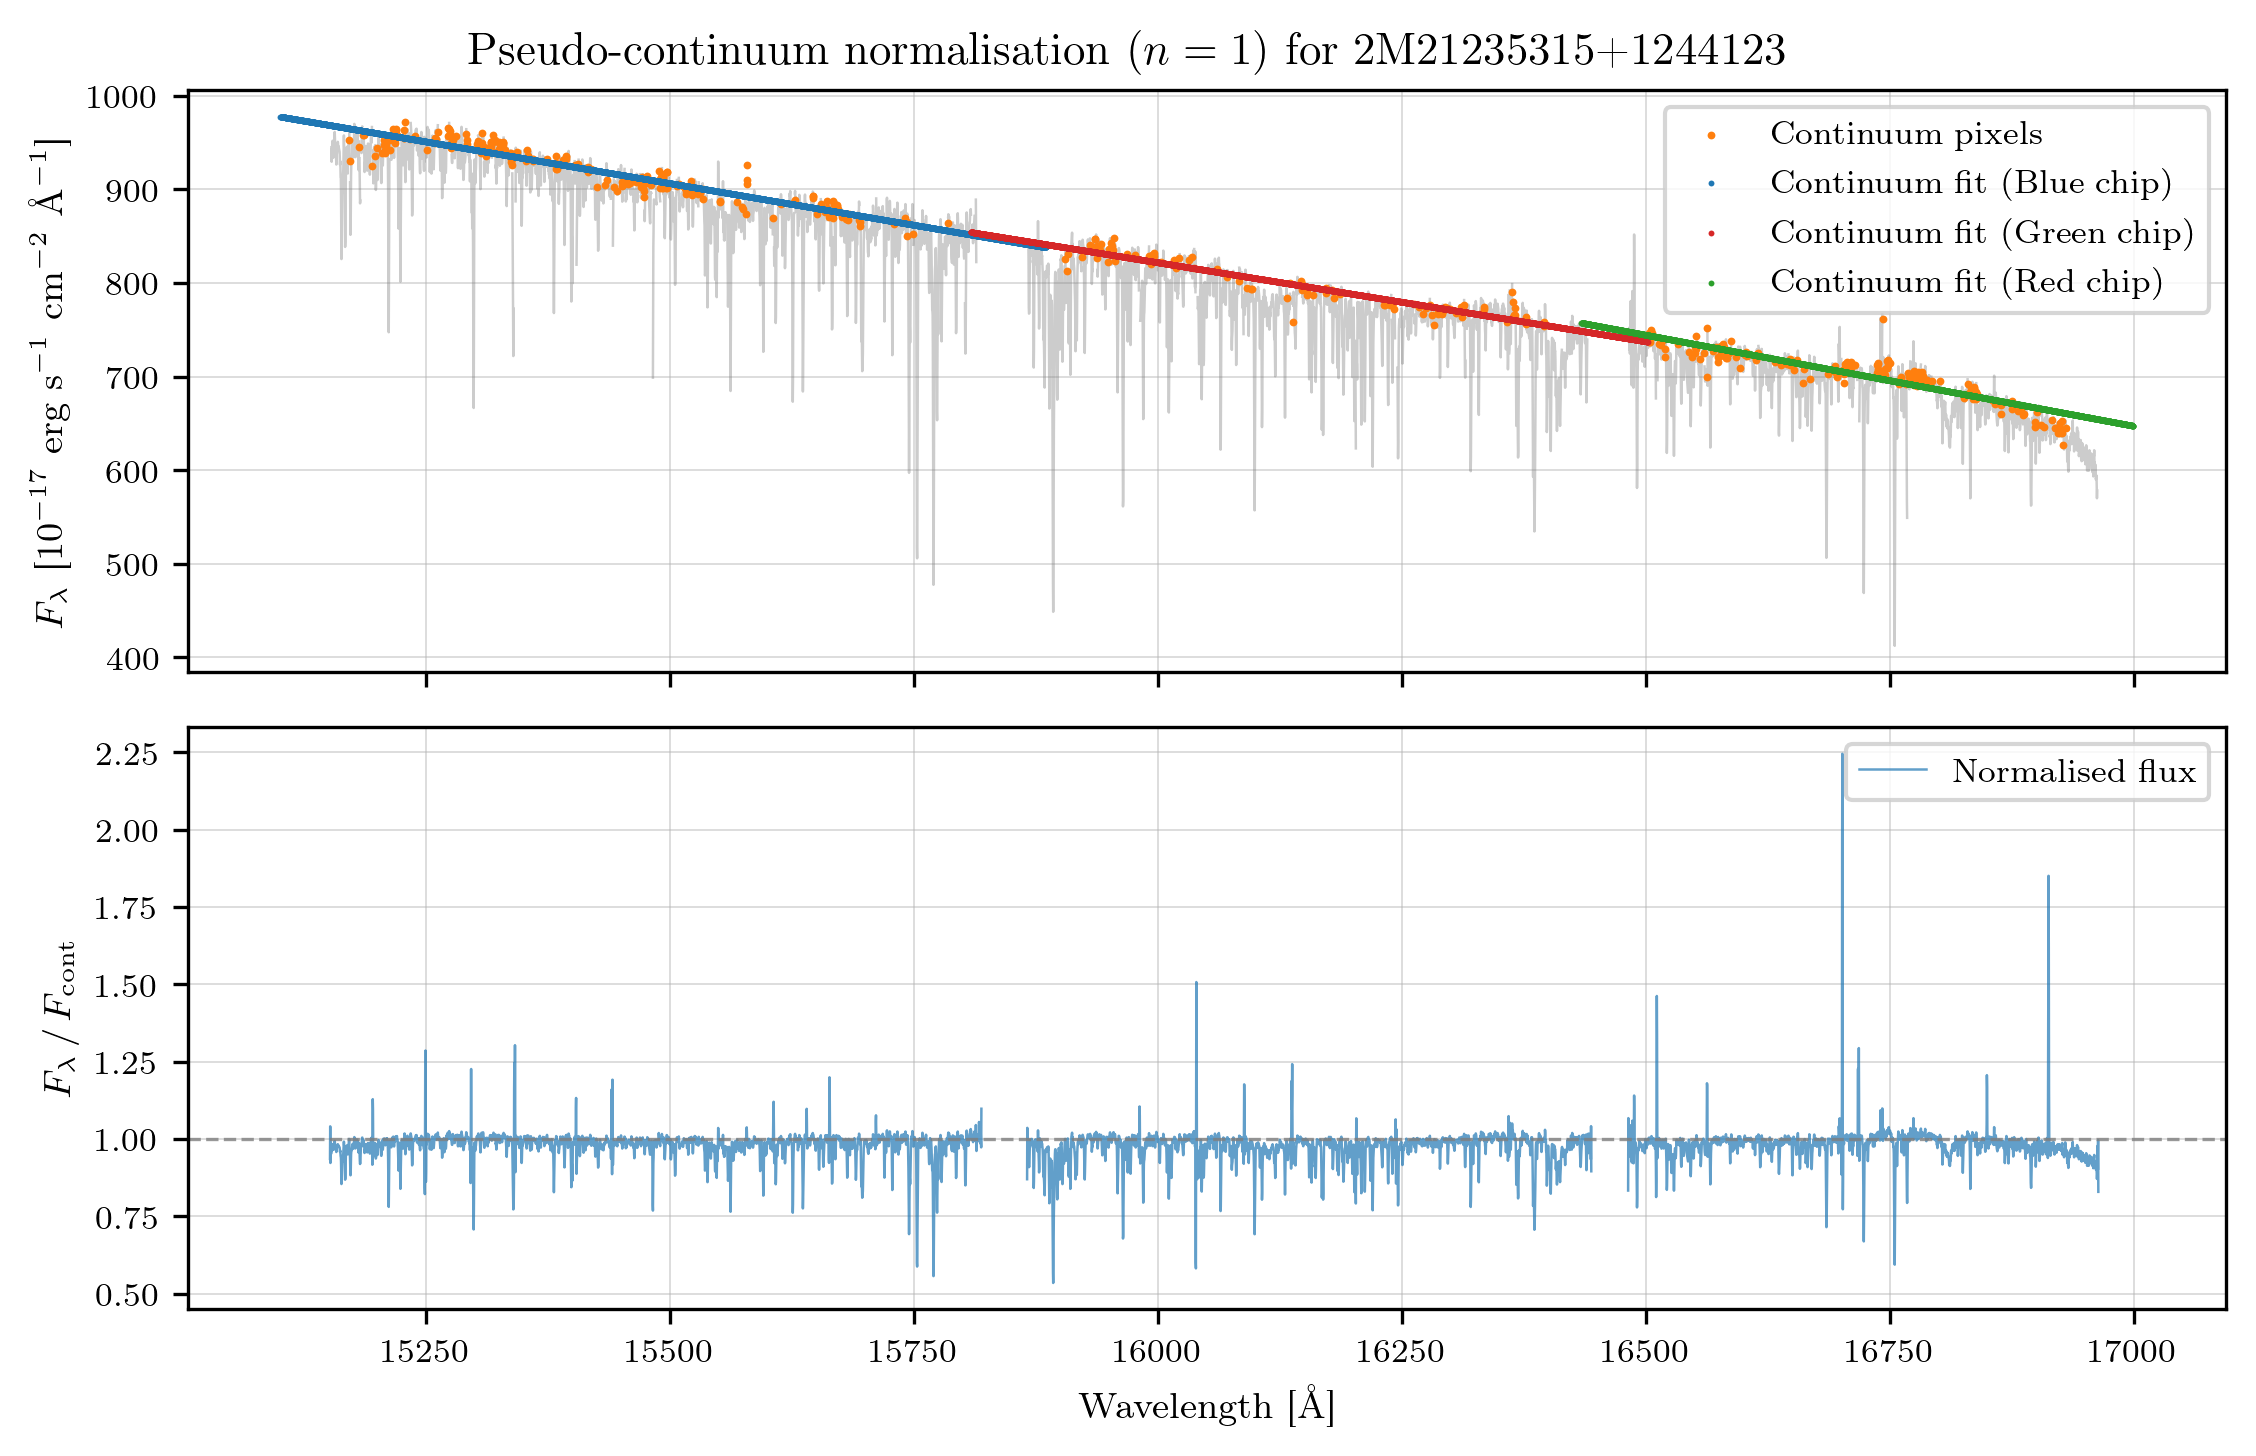

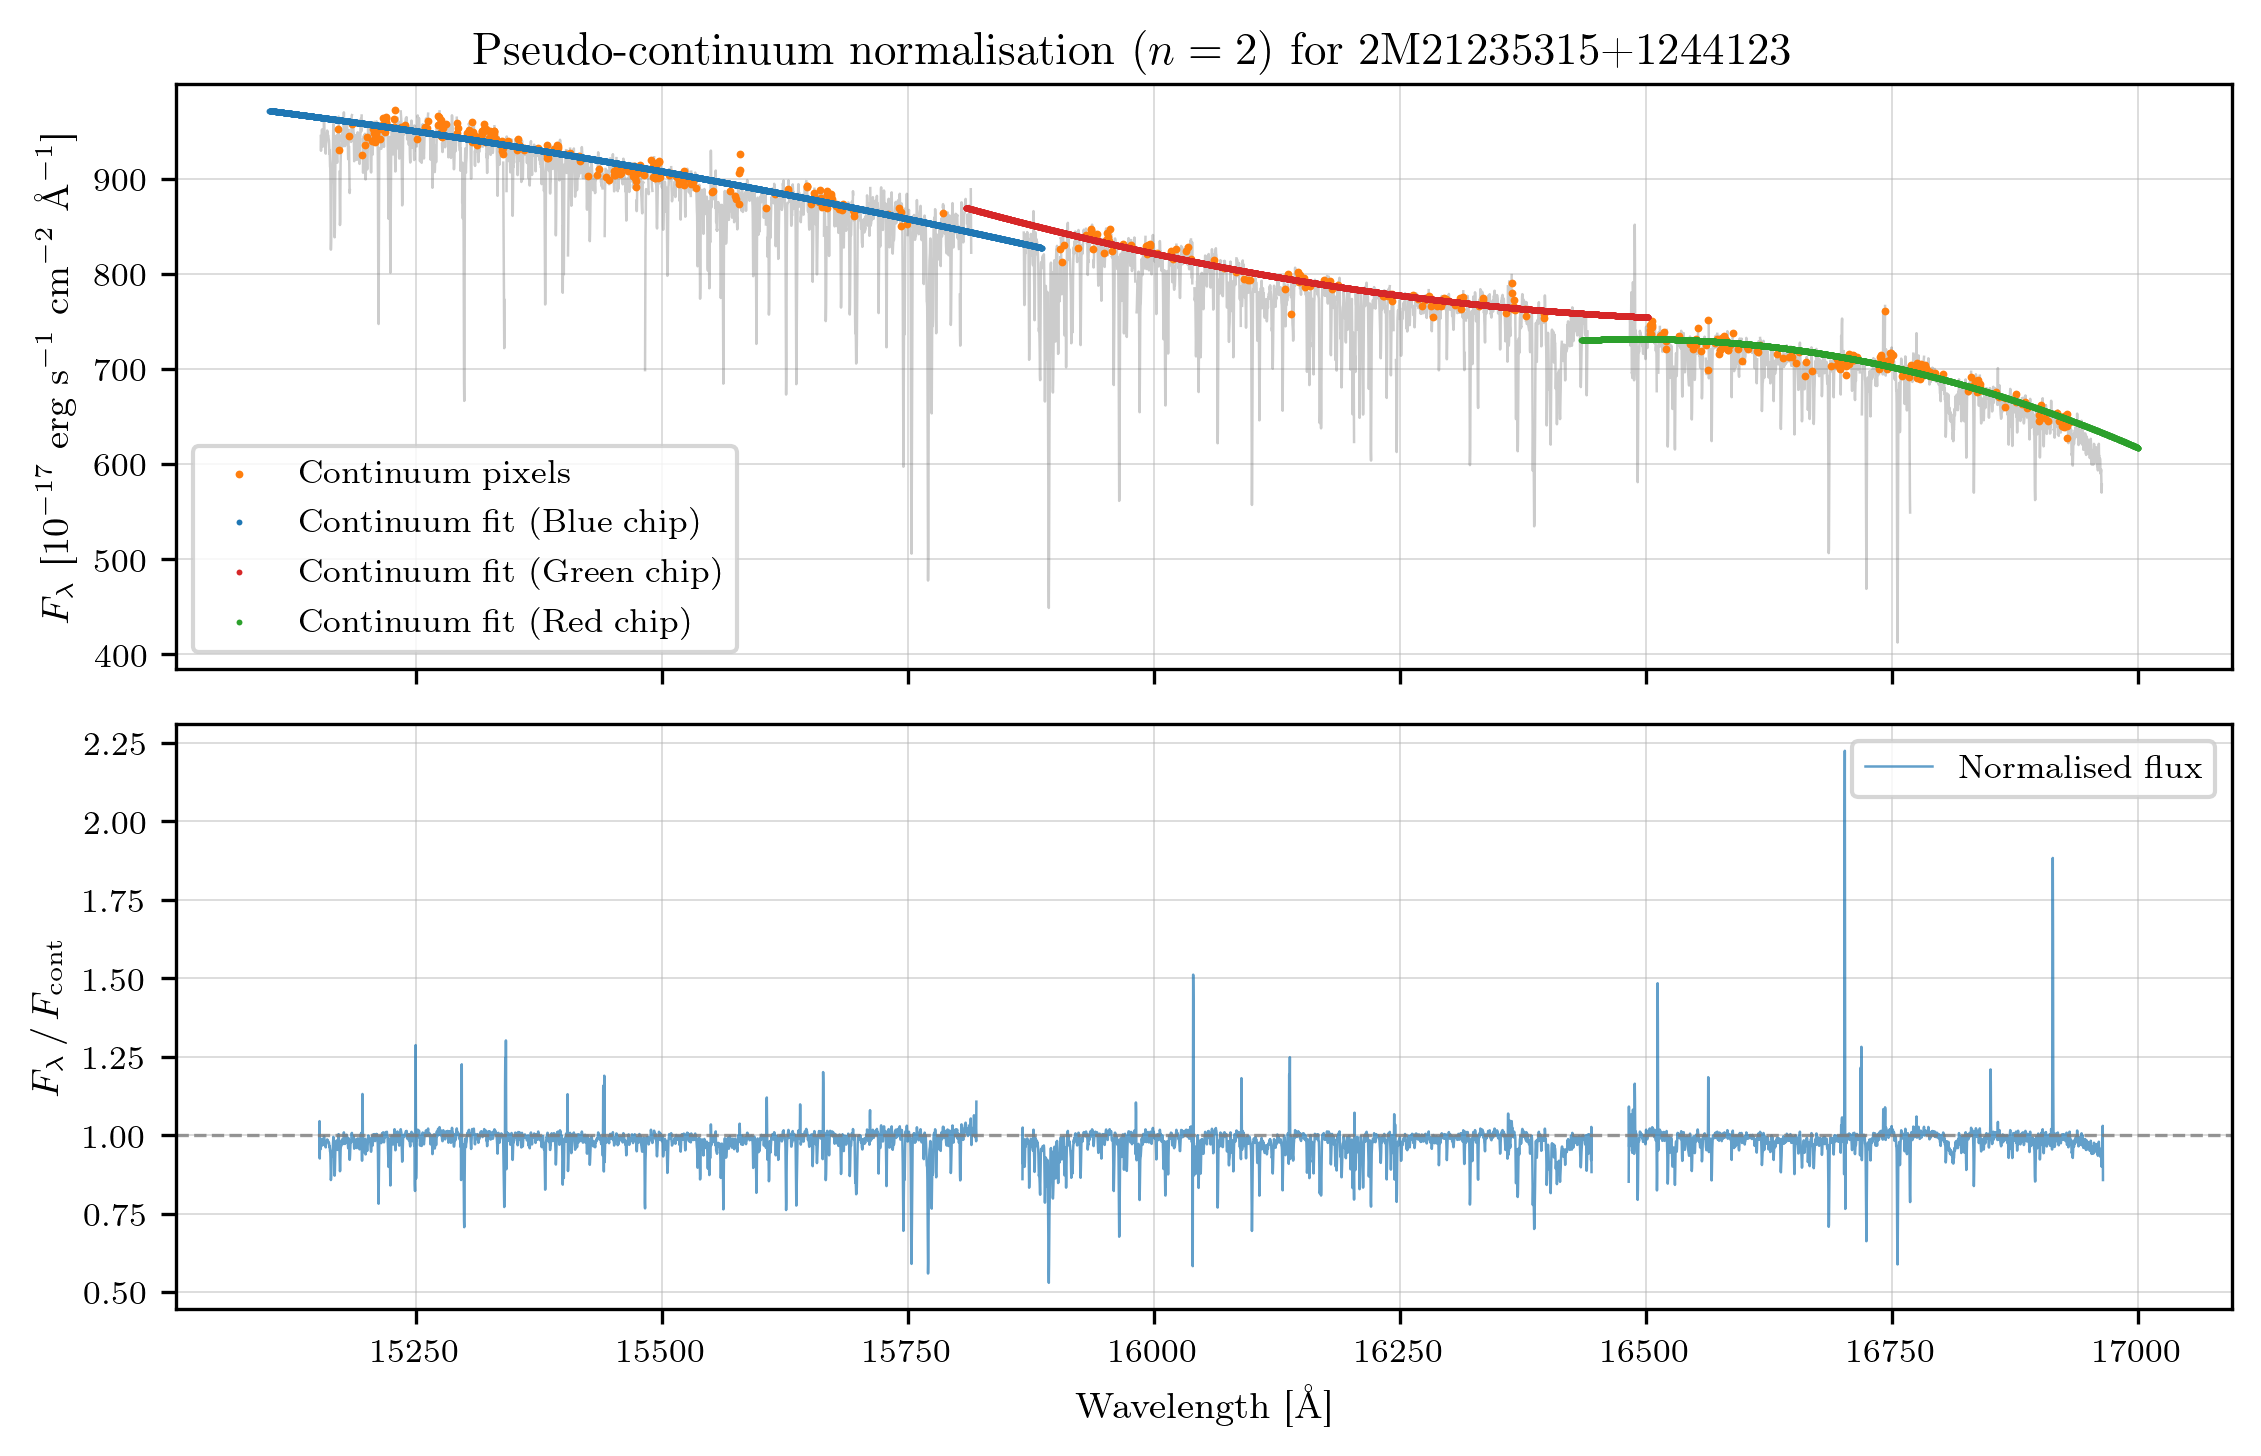

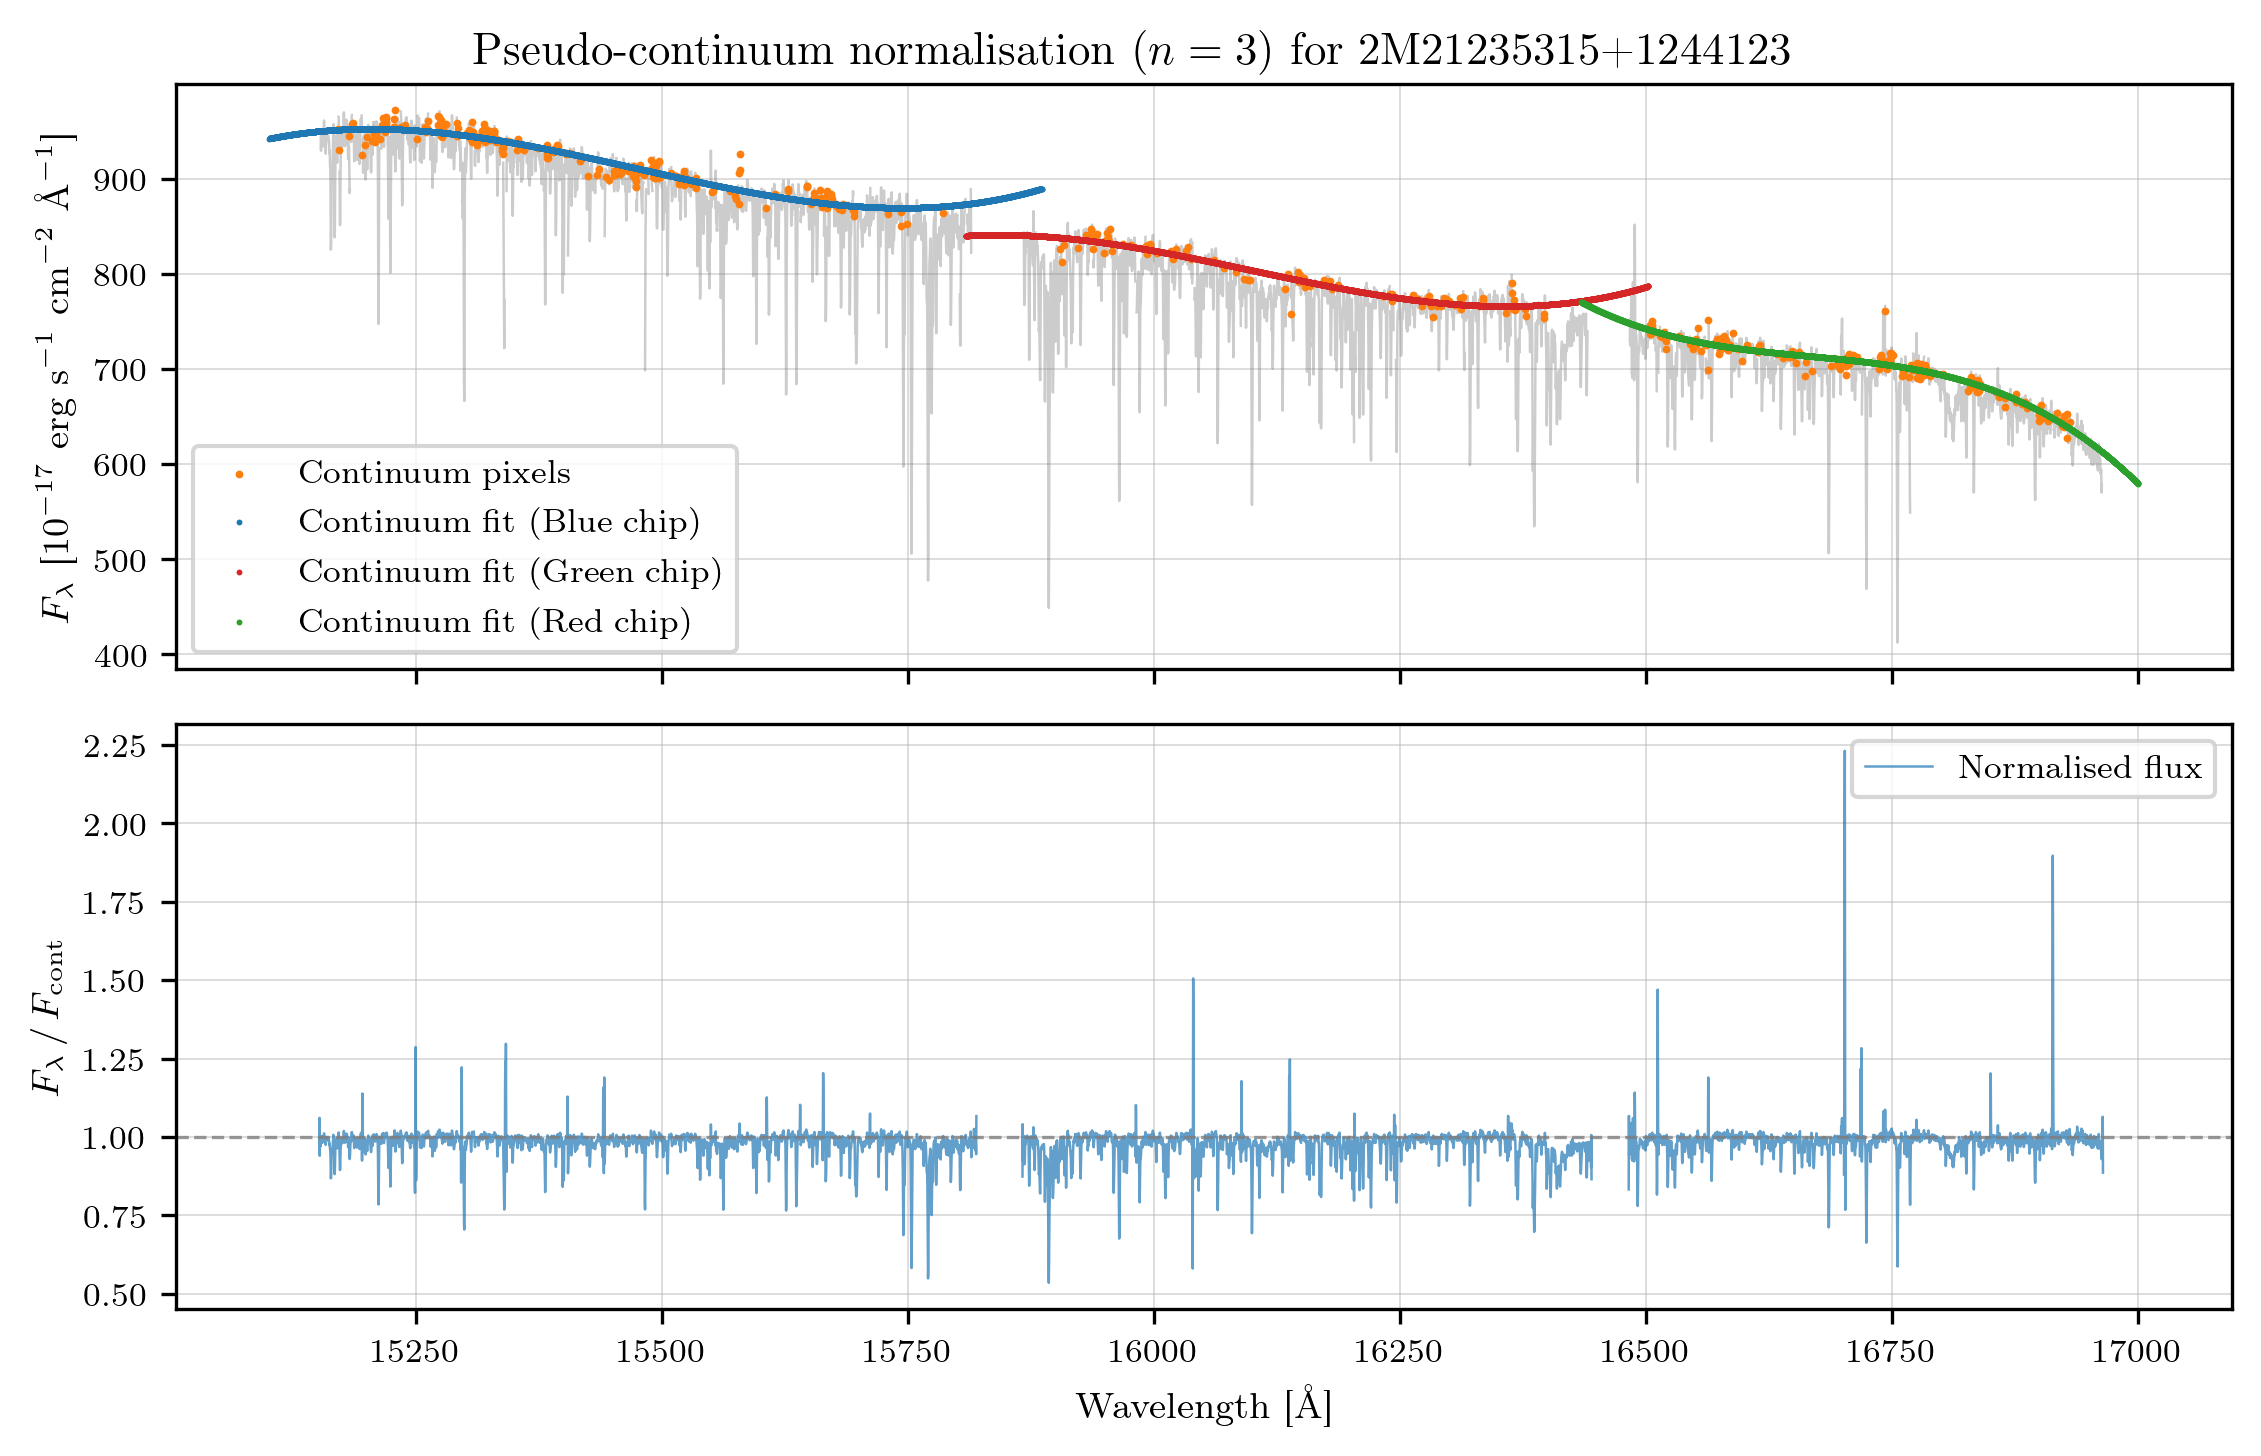

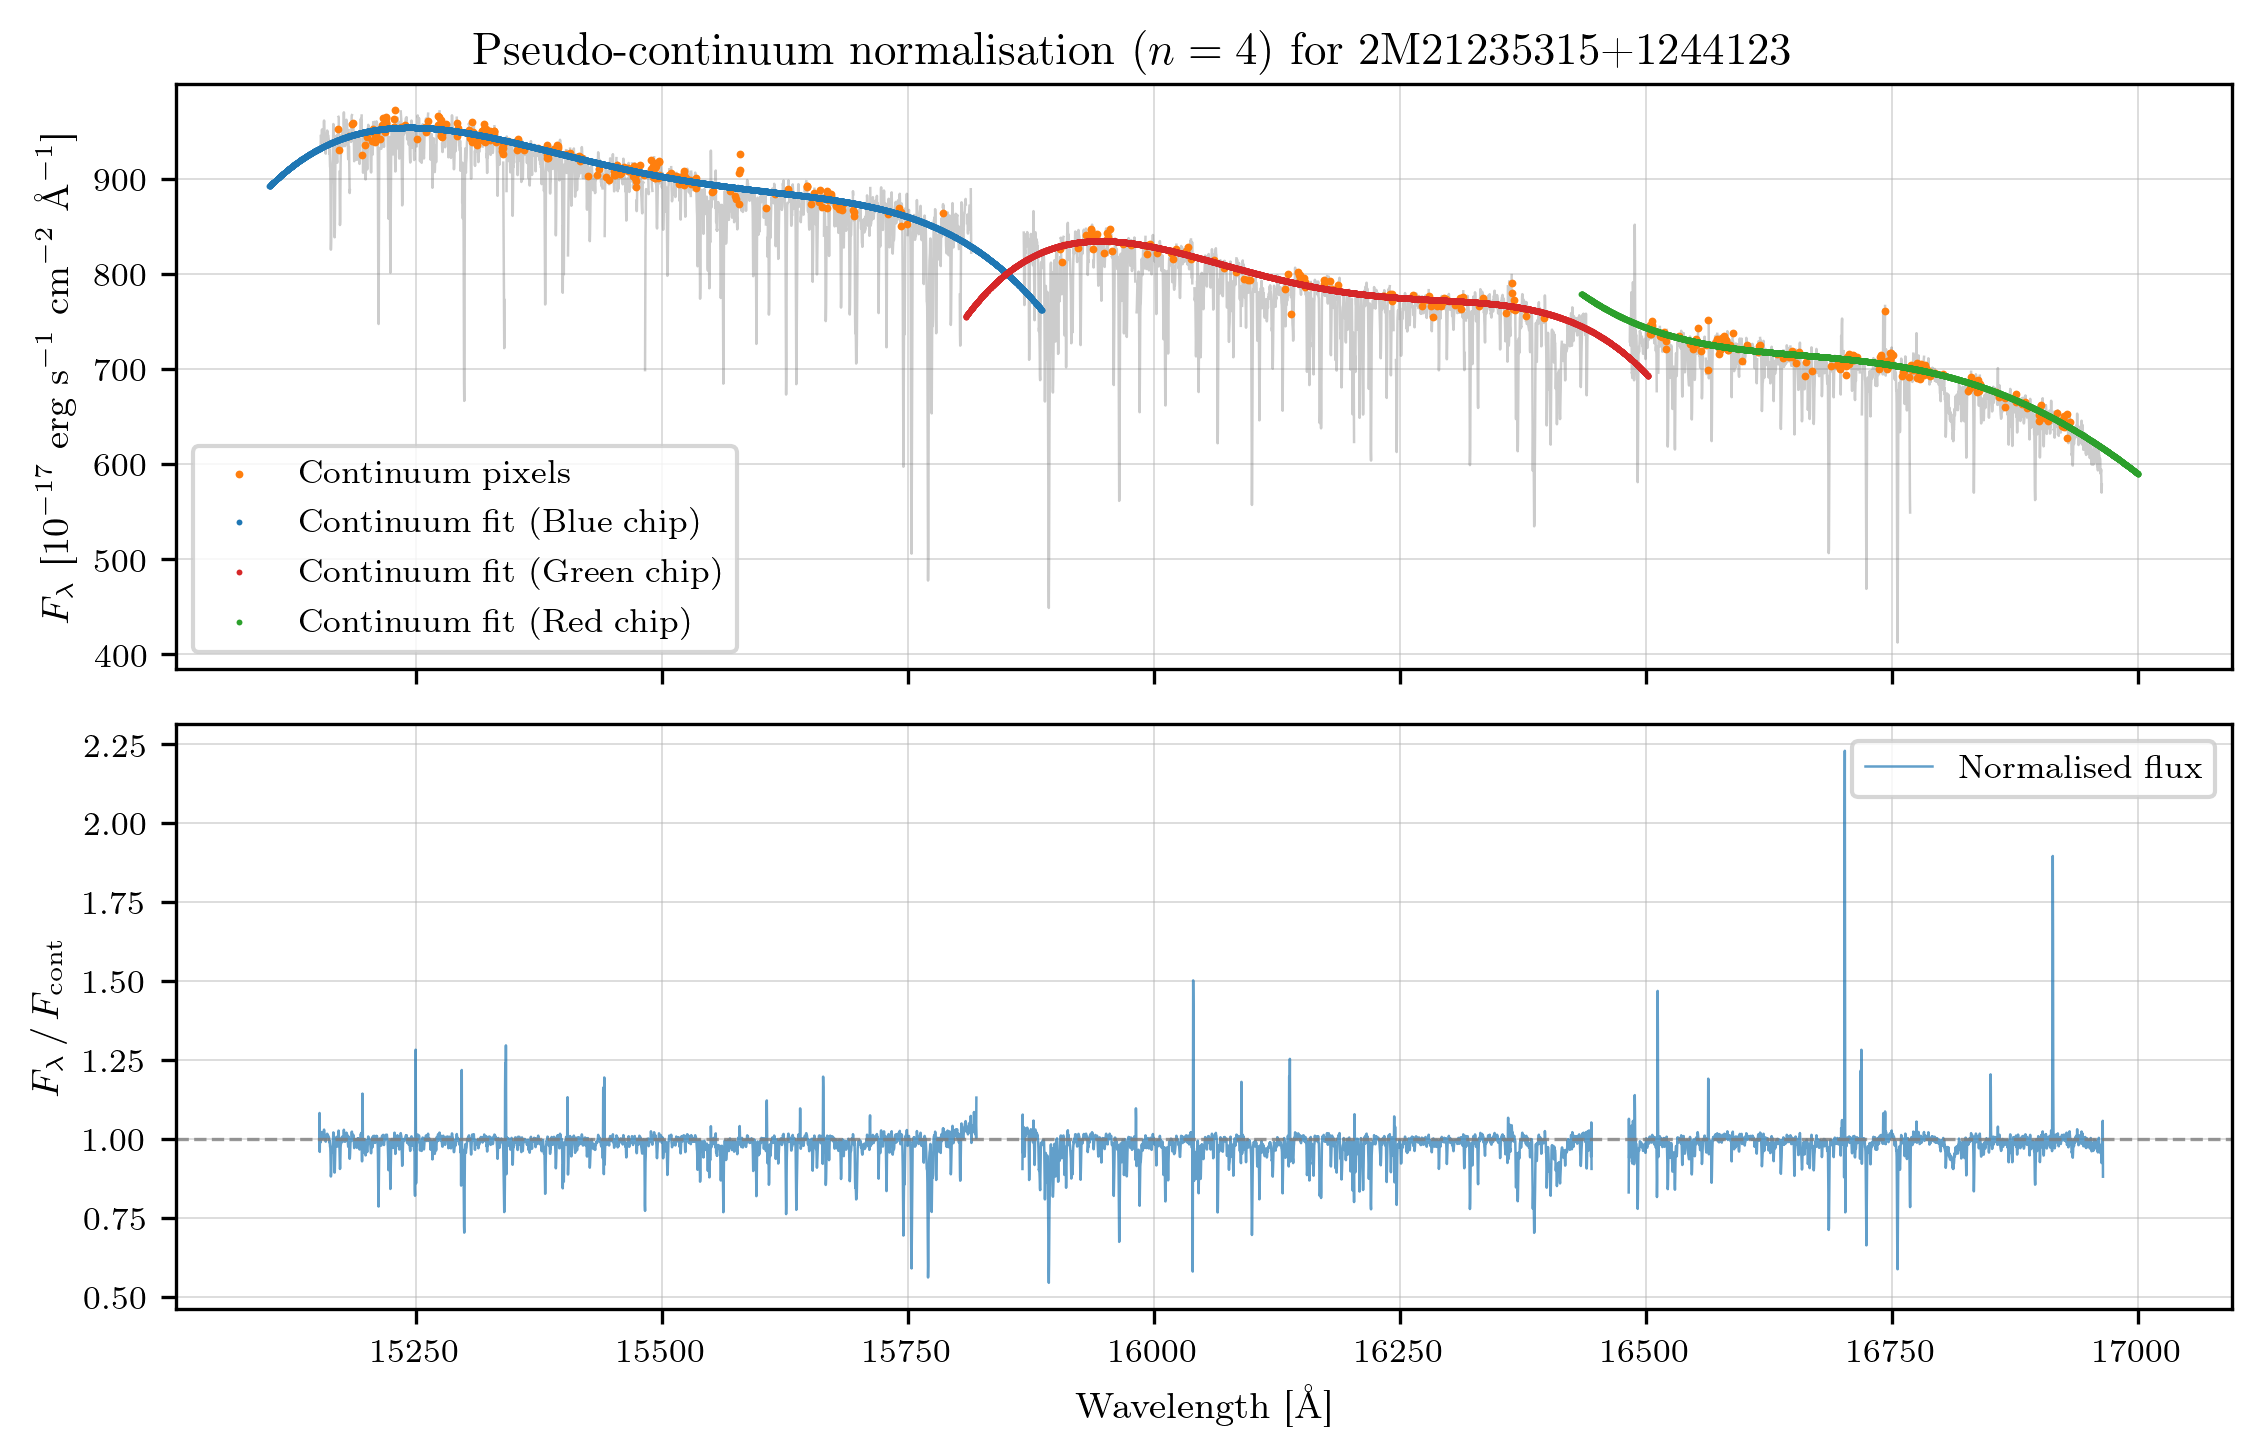

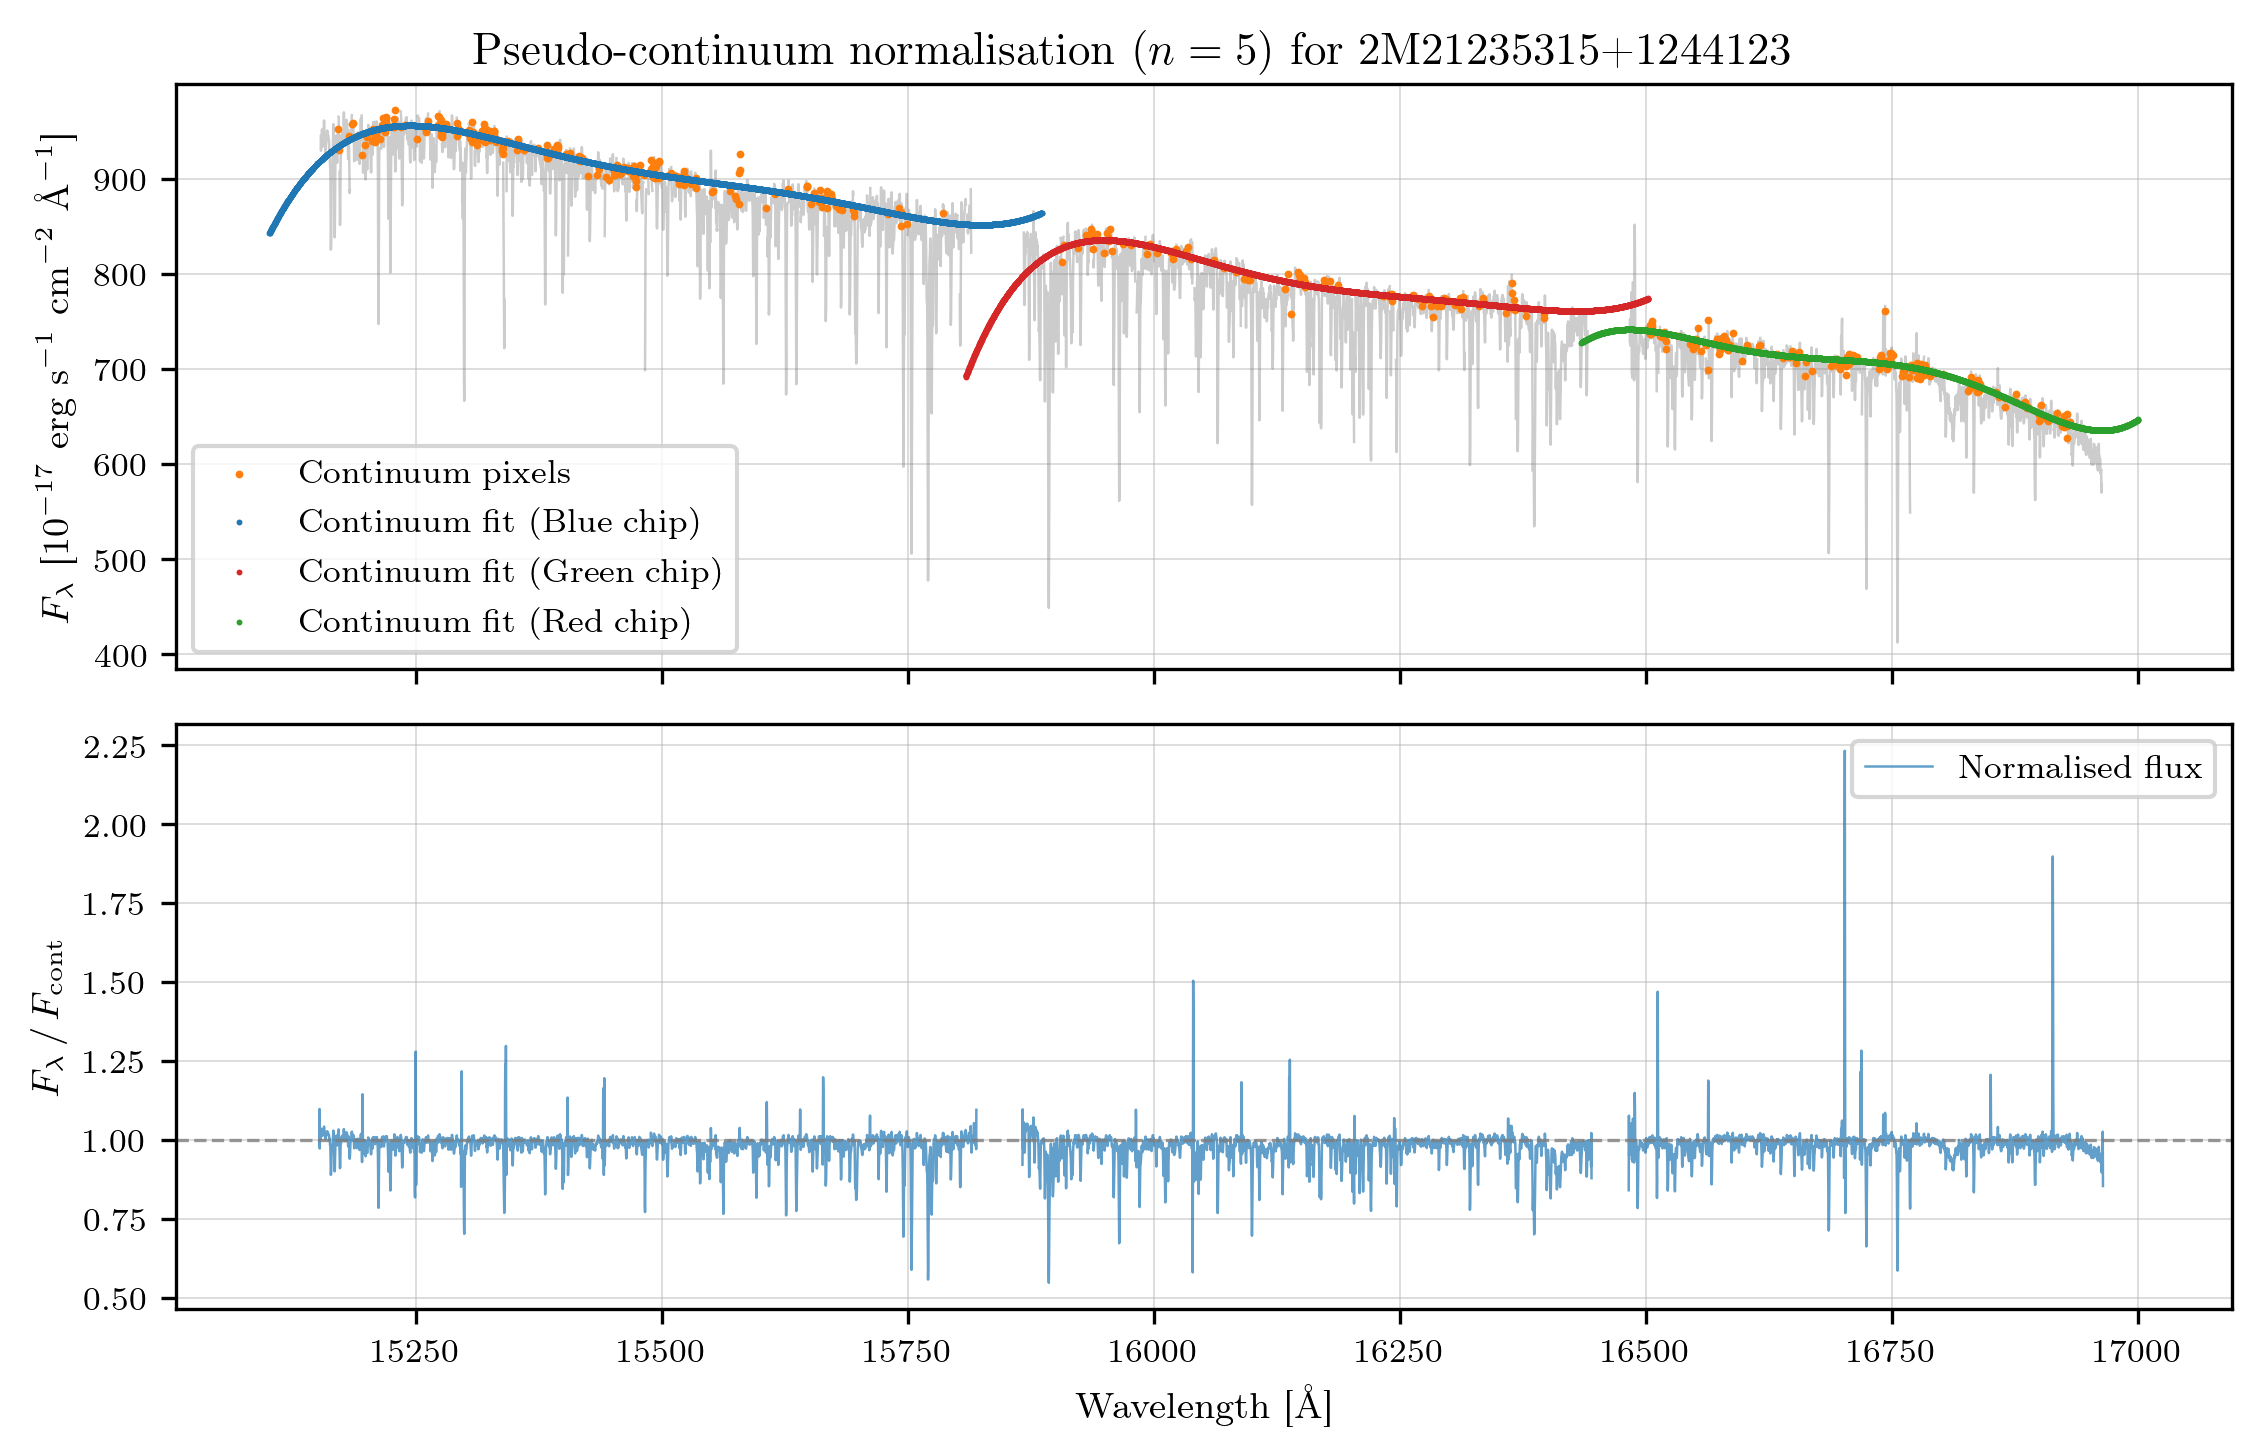

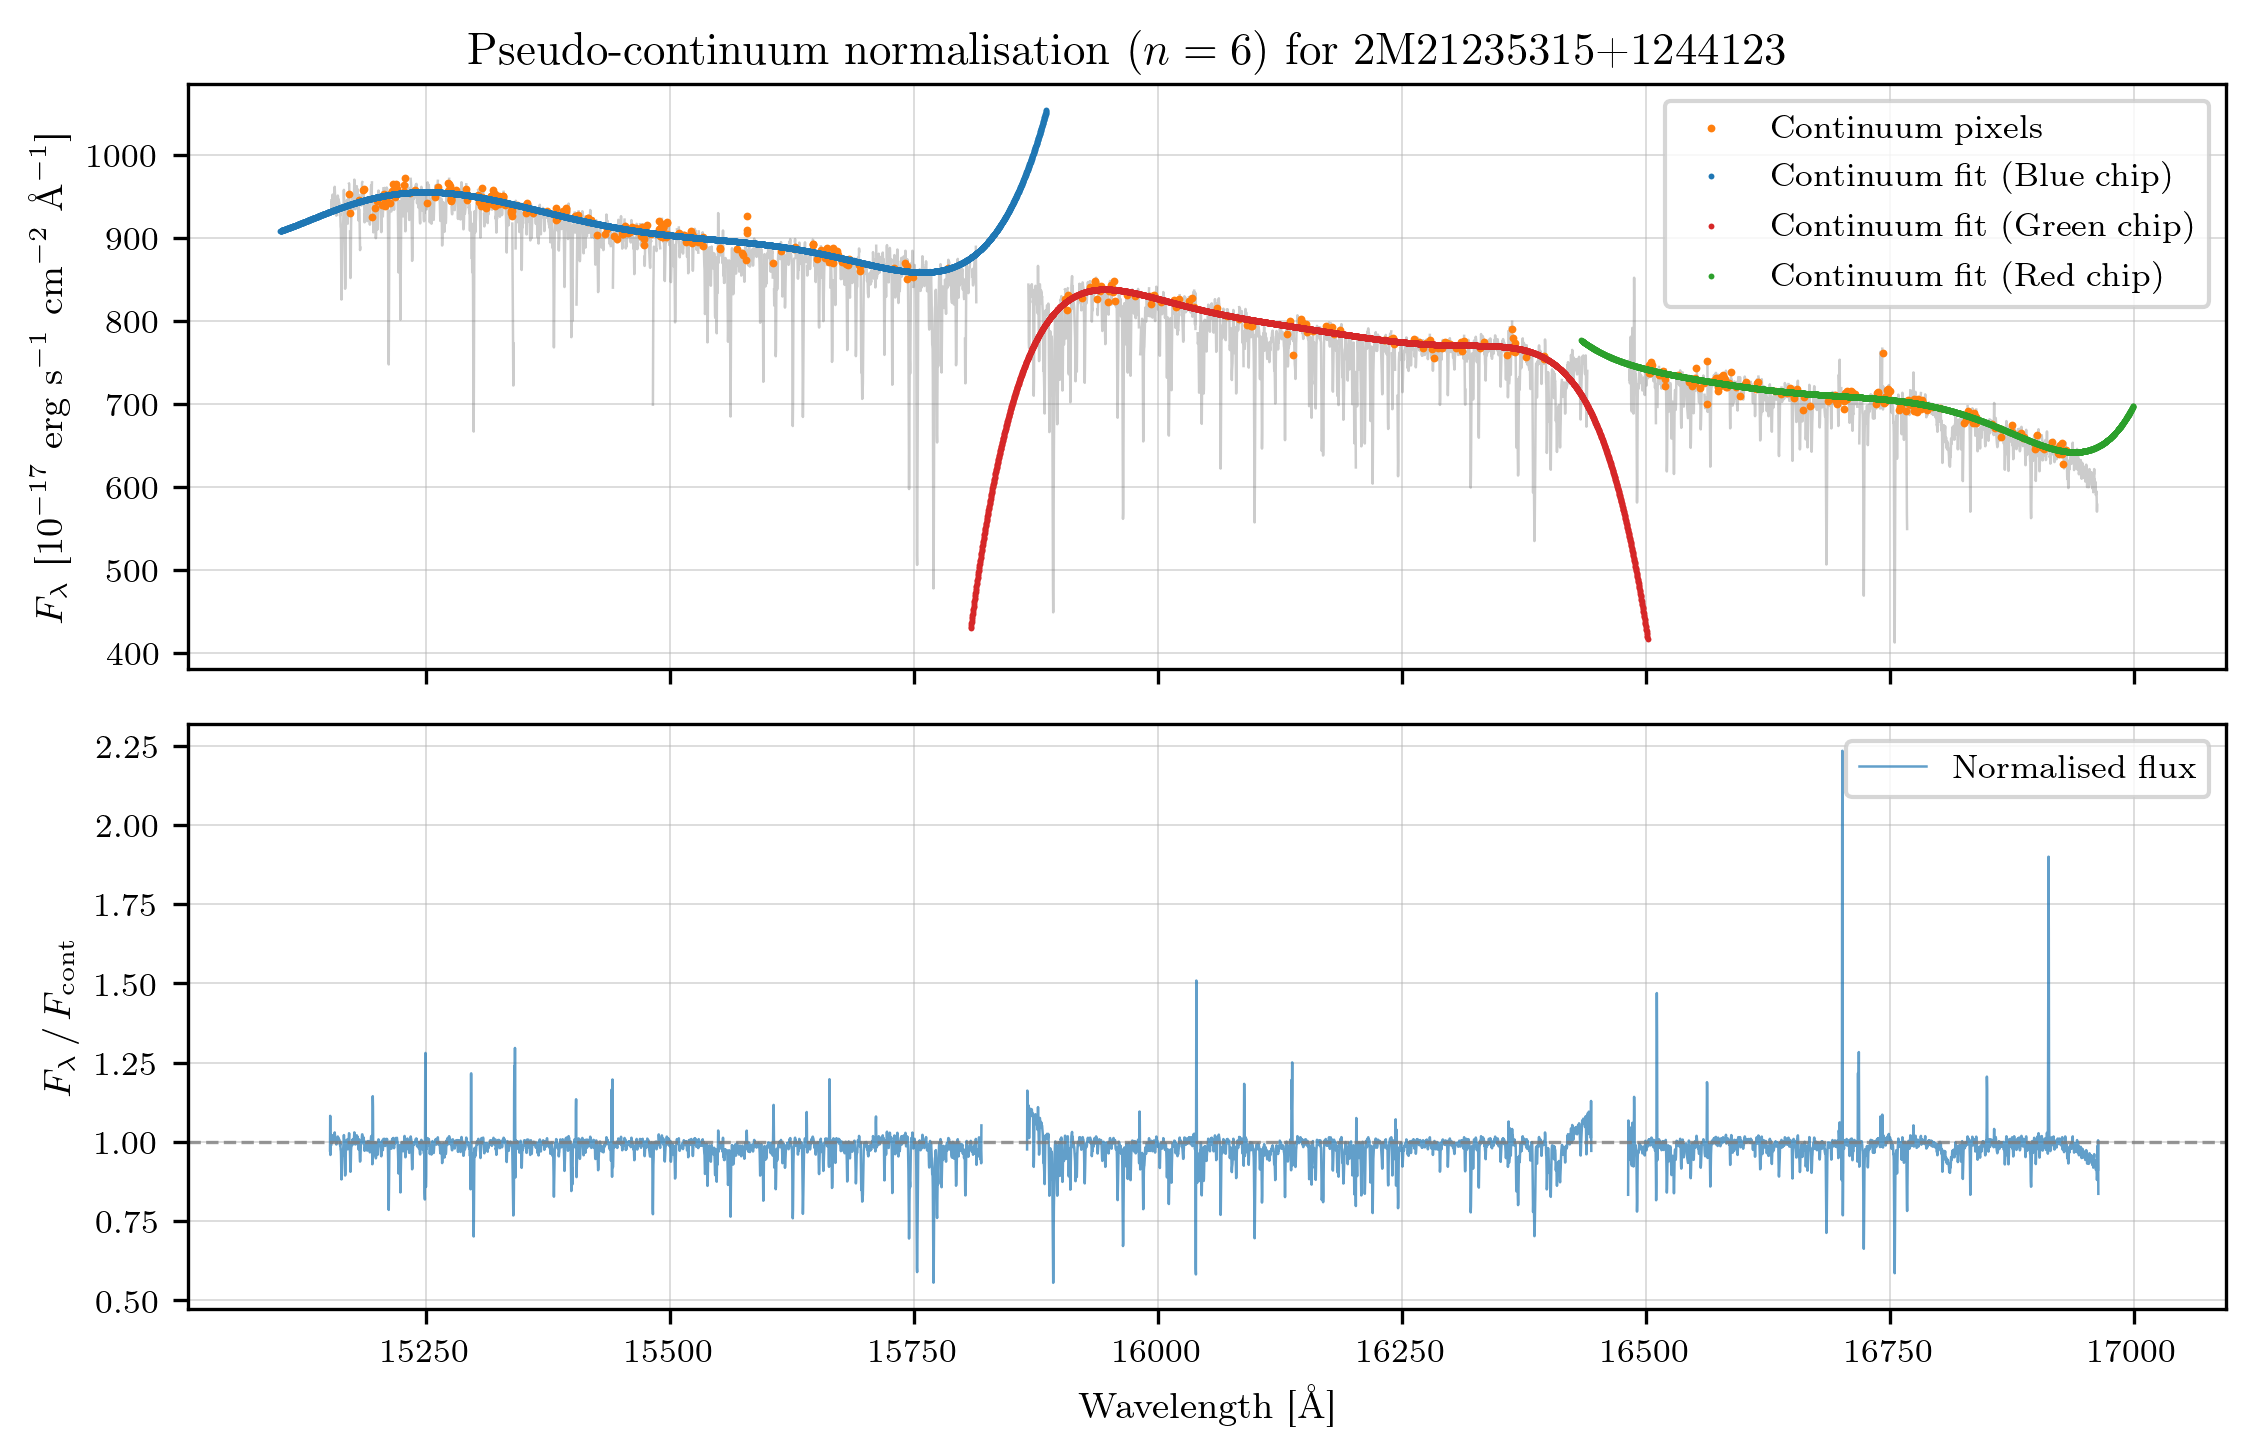

In [10]:
for n in range(1, 7):
    ax_raw, ax_norm = plot_normalized_spectrum(EXAMPLE_ID, EXAMPLE_TEL, EXAMPLE_FLD, n)
    ax_raw.get_figure().suptitle(rf"Pseudo-continuum normalisation ($n = {n}$) for {EXAMPLE_ID}", y=1.01)
    plt.show()


Of the plotted continuum normalizations, $n = 3$ and $n = 4$ look the most promising.